# Forecasting Los Angeles Home Values (Zillow ZHVI)
MGMTMSA 437 Forecasting and Time Series Analysis, final project

**Question:** How well can we forecast LA home values, and does adding mortgage rates beat
a pure trend model once rates jumped in 2022?

**Data**
- Zillow Home Value Index (ZHVI), all homes, mid tier, smoothed and seasonally adjusted, metro level.
  Source: https://www.zillow.com/research/data/
- 30-year fixed mortgage rate, weekly, averaged to monthly. Source: FRED `MORTGAGE30US`.
- Payroll jobs (total nonfarm, thousands, not seasonally adjusted) for LA County and Orange County.
  Source: BLS Current Employment Statistics via FRED `SMU06310840000000001`, `SMU06112440000000001`.

**Evaluation**
1. *Blind test*: an 80/20 split; every model forecasts the whole test window from the train end.
2. *Rolling-origin test*: refit every 3 months across the test window and forecast 12 months ahead,
   so every model is scored on the same horizons with the same information.

In [1]:
import warnings, logging
warnings.filterwarnings("ignore")
logging.getLogger("cmdstanpy").setLevel(logging.ERROR)
logging.getLogger("prophet").setLevel(logging.ERROR)

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pmdarima as pm
from xgboost import XGBRegressor          # load tree libraries before torch: on macOS the two
from lightgbm import LGBMRegressor        # bundled OpenMP runtimes otherwise segfault
import torch
from torch import nn
from prophet import Prophet
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

torch.set_num_threads(1)
DATA, FIG = Path("data"), Path("figures")
FIG.mkdir(exist_ok=True)
np.random.seed(0); torch.manual_seed(0)

# chart style: one accent hue, gray for actuals, recessive axes
BLUE, ORANGE, AQUA, GRAY, INK, MUTED = "#2a78d6", "#eb6834", "#1baf7a", "#8a8984", "#0b0b0b", "#52514e"
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": MUTED, "axes.titlecolor": INK,
    "axes.titleweight": "bold", "axes.titlesize": 12, "axes.titlelocation": "left",
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.grid": True, "grid.color": "#e8e7e2", "grid.linewidth": 0.6,
    "lines.linewidth": 2, "legend.frameon": False, "font.size": 10,
})
dollars = plt.FuncFormatter(lambda v, _: f"${v/1e3:,.0f}K")

Importing plotly failed. Interactive plots will not work.


## 1. Data

In [2]:
z = pd.read_csv(DATA / "Metro_zhvi.csv")
row = z[z.RegionName == "Los Angeles, CA"].iloc[0]
zhvi = row.iloc[5:].astype(float)
zhvi.index = pd.to_datetime(zhvi.index)

rate = (pd.read_csv(DATA / "MORTGAGE30US.csv", parse_dates=["observation_date"])
          .set_index("observation_date")["MORTGAGE30US"].resample("ME").mean())

def payroll(f):
    s = pd.read_csv(DATA / f, index_col=0, parse_dates=True).iloc[:, 0]
    s.index = s.index + pd.offsets.MonthEnd(0)
    return s
jobs_c = pd.DataFrame({"Los Angeles County": payroll("la_county_payroll.csv"),
                       "Orange County": payroll("orange_county_payroll.csv")})
jobs = jobs_c.sum(axis=1)                # LA + Orange County payroll jobs, thousands

df = pd.concat([zhvi.rename("zhvi"), rate.rename("rate"), jobs.rename("jobs")], axis=1, sort=True).dropna()
df["logp"] = np.log(df.zhvi)
df["g"] = 100 * df.logp.diff()            # monthly growth, %
df["yoy"] = 100 * (df.zhvi / df.zhvi.shift(12) - 1)
df["jg"] = 100 * np.log(jobs).diff(12).reindex(df.index)   # payroll job growth over 12 months, % (removes seasonality)
print(f"{df.index.min():%Y-%m} to {df.index.max():%Y-%m}, {len(df)} months")

# neighborhood-level ZHVI for the LA metro (Zillow's neighborhood file, LA-metro subset)
nr = pd.read_csv(DATA / "la_nbhd_zhvi.csv", dtype={"RegionID": str}).set_index("RegionID")
nb_info = nr[["RegionName", "City", "CountyName"]].copy()
dup = nb_info.RegionName.duplicated(keep=False)
nb_info["label"] = np.where(dup | (nb_info.City != "Los Angeles") & (nb_info.City != nb_info.RegionName),
                            nb_info.RegionName + ", " + nb_info.City, nb_info.RegionName)
nb_info["label"] = np.where(nb_info.RegionName == nb_info.City, nb_info.RegionName, nb_info["label"])
ZA = nr.drop(columns=["RegionName", "City", "CountyName"]).T
ZA.index = pd.to_datetime(ZA.index)
ZA = ZA.loc[df.index]
ZA = ZA.loc[:, ZA.loc["2020-01-31":].notna().all()]   # data since 2020: shock + trend analysis
Z = ZA.loc[:, ZA.notna().all()]                       # full 2000-2026 history: factor model + forecasts
G = 100 * np.log(Z).diff()                            # neighborhood monthly growth, %
print(f"neighborhoods: {ZA.shape[1]} with data since 2020, {Z.shape[1]} with full history "
      f"({nb_info.loc[Z.columns].CountyName.value_counts().to_dict()})")
nb_xy = (pd.read_csv(DATA / "la_nbhd_centroids.csv", dtype={"RegionID": str}).set_index("RegionID")[["lat", "lon"]])
df[["zhvi", "rate"]].describe().round(2)

2000-01 to 2026-08, 320 months
neighborhoods: 496 with data since 2020, 405 with full history ({'Los Angeles County': 329, 'Orange County': 76})


,zhvi,rate
count,320.00,320.00
mean,556388.80,5.23
std,210283.13,1.39
min,221912.27,2.68
25%,397675.30,3.98
50%,514029.41,5.23
75%,667156.77,6.35
max,965633.77,8.52


In [3]:
N = len(df)
N_TRAIN = int(0.8 * N)
H = N - N_TRAIN
train_end = df.index[N_TRAIN - 1]
print(f"train: {df.index[0]:%Y-%m} to {train_end:%Y-%m} ({N_TRAIN} months)")
print(f"test:  {df.index[N_TRAIN]:%Y-%m} to {df.index[-1]:%Y-%m} ({H} months)")

train: 2000-01 to 2021-04 (256 months)
test:  2021-05 to 2026-08 (64 months)


## 2. Exploratory analysis

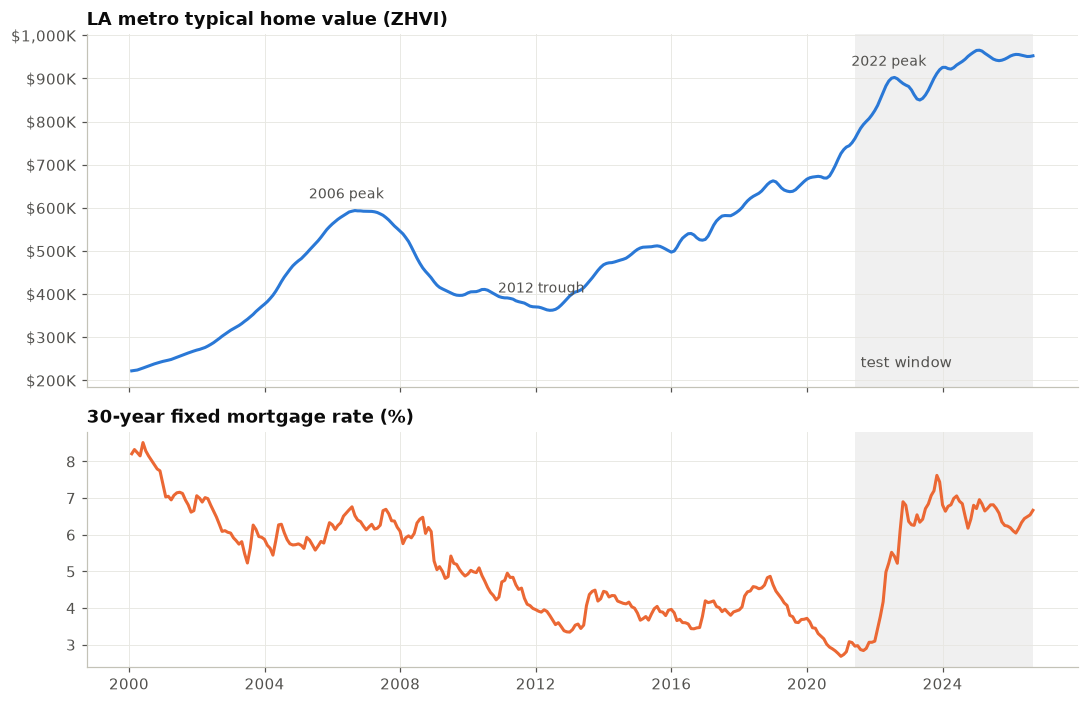

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6.5), sharex=True, gridspec_kw={"height_ratios": [3, 2]})
ax = axes[0]
ax.plot(df.index, df.zhvi, color=BLUE)
ax.axvspan(df.index[N_TRAIN], df.index[-1], color=GRAY, alpha=0.12, lw=0)
ax.text(df.index[N_TRAIN + 2], df.zhvi.min(), "test window", color=MUTED, va="bottom")
for d, lab in [("2006-05-31", "2006 peak"), ("2012-02-29", "2012 trough"), ("2022-05-31", "2022 peak")]:
    d = pd.Timestamp(d); ax.annotate(lab, (d, df.zhvi[d]), xytext=(0, 10), textcoords="offset points",
                                     ha="center", color=MUTED, fontsize=9)
ax.yaxis.set_major_formatter(dollars)
ax.set_title("LA metro typical home value (ZHVI)")
ax = axes[1]
ax.plot(df.index, df.rate, color=ORANGE)
ax.axvspan(df.index[N_TRAIN], df.index[-1], color=GRAY, alpha=0.12, lw=0)
ax.set_title("30-year fixed mortgage rate (%)")
ax.xaxis.set_major_locator(mdates.YearLocator(4))
fig.tight_layout(); fig.savefig(FIG / "01_level_and_rate.png"); plt.show()

In [5]:
peak = df.zhvi.idxmax()
print(f"Peak: {peak:%Y-%m} at ${df.zhvi.max():,.0f}; latest {df.index[-1]:%Y-%m} ${df.zhvi.iloc[-1]:,.0f} "
      f"({100*(df.zhvi.iloc[-1]/df.zhvi.max()-1):+.1f}% from peak)")
cagr = lambda a, b: 100 * ((df.zhvi[b] / df.zhvi[a]) ** (12 / ((pd.Timestamp(b) - pd.Timestamp(a)).days / 30.44)) - 1)
print(f"CAGR 2000-2026: {cagr(df.index[0], df.index[-1]):.1f}%/yr")
print(f"2006-05 to 2012-02 drawdown: {100*(df.zhvi['2012-02-29']/df.zhvi['2006-05-31']-1):.1f}%")

Peak: 2025-01 at $965,634; latest 2026-08 $952,601 (-1.3% from peak)
CAGR 2000-2026: 5.6%/yr
2006-05 to 2012-02 drawdown: -37.2%


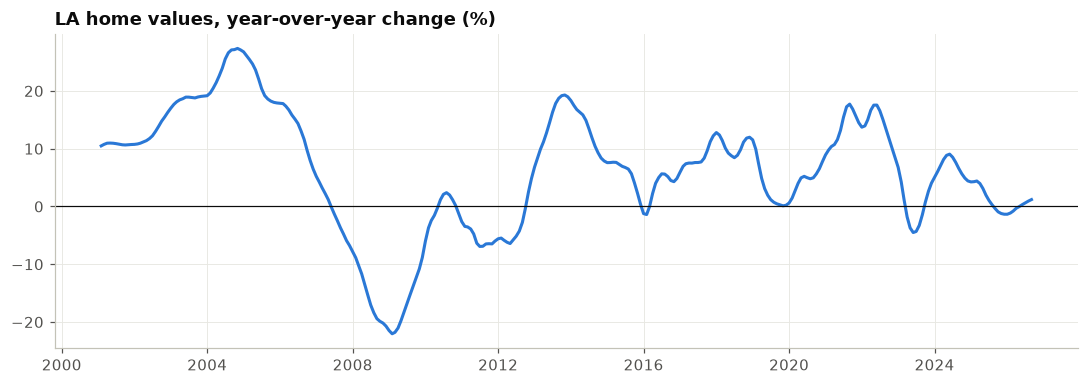

In [6]:
fig, ax = plt.subplots(figsize=(10, 3.6))
ax.plot(df.index, df.yoy, color=BLUE)
ax.axhline(0, color=INK, lw=0.8)
ax.set_title("LA home values, year-over-year change (%)")
fig.tight_layout(); fig.savefig(FIG / "02_yoy.png"); plt.show()

### Stationarity
Log levels clearly have a unit root. Monthly growth is borderline: ZHVI is smoothed and LA had
long boom-bust swings, so growth is very persistent (high ACF at low lags). That persistence makes one-step-ahead forecasts look
deceptively accurate, which is why we judge models on multi-month horizons.

ADF log level       stat= -1.45  p=0.557
ADF monthly growth  stat= -2.35  p=0.158


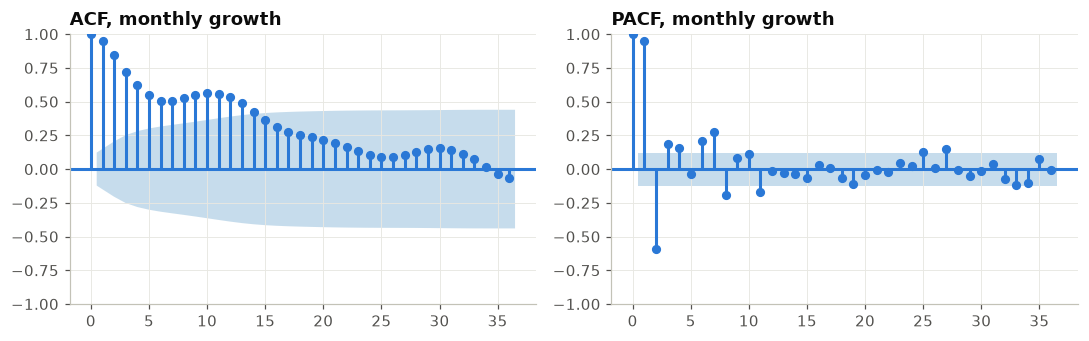

In [7]:
for name, s in [("log level", df.logp), ("monthly growth", df.g.dropna())]:
    stat, p, *_ = adfuller(s.iloc[:N_TRAIN].dropna(), autolag="AIC")
    print(f"ADF {name:15s} stat={stat:6.2f}  p={p:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
plot_acf(df.g.dropna().iloc[:N_TRAIN], lags=36, ax=axes[0], color=BLUE, vlines_kwargs={"colors": BLUE})
plot_pacf(df.g.dropna().iloc[:N_TRAIN], lags=36, ax=axes[1], color=BLUE, vlines_kwargs={"colors": BLUE}, method="ywm")
axes[0].set_title("ACF, monthly growth"); axes[1].set_title("PACF, monthly growth")
fig.tight_layout(); fig.savefig(FIG / "03_acf_pacf.png"); plt.show()

### Do mortgage rates lead home-value growth?
Correlation between the 12-month change in the mortgage rate and LA home-value growth
k months later (training sample only).

In [8]:
d12 = df.rate.diff(12)
tr = df.iloc[:N_TRAIN]
lead_corr = pd.Series({k: tr.yoy.corr(d12.iloc[:N_TRAIN].shift(k)) for k in range(0, 25, 3)})
print(lead_corr.round(2).to_string())

0     0.33
3     0.24
6     0.11
9    -0.02
12   -0.14
15   -0.23
18   -0.29
21   -0.33
24   -0.35


## 3. Models
Every model forecasts **log home values** for the next `h` months from information up to the
forecast origin. Machine-learning and neural models predict monthly growth and are rolled forward
recursively, so they can extrapolate a trend (trees can't extrapolate raw price levels).

In [9]:
def to_levels(last_logp, g_path):
    """Monthly growth path (%) -> log-level path."""
    return last_logp + np.cumsum(g_path) / 100

# --- baseline: random walk with drift ---
def f_naive(d, h, **_):
    return to_levels(d.logp.iloc[-1], np.repeat(d.g.dropna().mean(), h))

# --- ARIMA on log level; order chosen once on the training set ---
ARIMA_SPEC = pm.auto_arima(df.logp.iloc[:N_TRAIN], seasonal=False, stepwise=True,
                           information_criterion="aic", suppress_warnings=True)
print("ARIMA:", ARIMA_SPEC.order, "intercept:", ARIMA_SPEC.with_intercept)

def f_arima(d, h, **_):
    m = pm.ARIMA(order=ARIMA_SPEC.order, with_intercept=ARIMA_SPEC.with_intercept,
                 suppress_warnings=True).fit(d.logp.values)
    return m.predict(h)

# --- Holt's damped trend (series is already seasonally adjusted, so no seasonal term) ---
def f_holt(d, h, **_):
    m = ExponentialSmoothing(d.logp.values, trend="add", damped_trend=True,
                             initialization_method="estimated").fit()
    return m.forecast(h)

# --- Prophet ---
def f_prophet(d, h, **_):
    m = Prophet(yearly_seasonality=False, weekly_seasonality=False, daily_seasonality=False)
    m.fit(pd.DataFrame({"ds": d.index, "y": d.logp.values}))
    fut = m.make_future_dataframe(periods=h, freq="ME")
    return m.predict(fut).yhat.values[-h:]

ARIMA: (1, 1, 2) intercept: True


In [10]:
# --- gradient-boosted trees on lagged growth ---
def tree_features(g):
    X = pd.DataFrame({f"lag{k}": g.shift(k) for k in range(1, 13)})
    for w in (3, 6, 12):
        X[f"ma{w}"] = g.shift(1).rolling(w).mean()
    return X

def make_tree(kind):
    if kind == "xgb":
        return XGBRegressor(n_estimators=400, max_depth=3, learning_rate=0.03, subsample=0.8, random_state=0, n_jobs=1)
    return LGBMRegressor(n_estimators=400, num_leaves=15, learning_rate=0.03, min_child_samples=10,
                         subsample=0.8, subsample_freq=1, random_state=0, n_jobs=1, verbose=-1)

def f_tree(d, h, kind, **_):
    g = d.g.dropna().reset_index(drop=True)
    data = pd.concat([tree_features(g), g.rename("y")], axis=1).dropna()
    m = make_tree(kind).fit(data.drop(columns="y"), data.y)
    hist = list(g)
    for _ in range(h):
        s = pd.Series(hist + [np.nan])
        hist.append(float(m.predict(tree_features(s).iloc[[-1]])[0]))
    return to_levels(d.logp.iloc[-1], hist[-h:])

f_xgb = lambda d, h, **k: f_tree(d, h, "xgb")
f_lgbm = lambda d, h, **k: f_tree(d, h, "lgbm")

In [11]:
# --- LSTM / GRU on standardized monthly growth ---
WINDOW = 24

class RNN(nn.Module):
    def __init__(self, cell, hidden=32):
        super().__init__()
        self.rnn = {"lstm": nn.LSTM, "gru": nn.GRU}[cell](1, hidden, batch_first=True)
        self.head = nn.Linear(hidden, 1)
    def forward(self, x):
        out, _ = self.rnn(x)
        return self.head(out[:, -1])

def f_rnn(d, h, cell, epochs=400, patience=40, **_):
    torch.manual_seed(0)
    g = d.g.dropna().values
    mu, sd = g.mean(), g.std()
    zs = (g - mu) / sd
    X = np.stack([zs[i:i + WINDOW] for i in range(len(zs) - WINDOW)])
    y = zs[WINDOW:]
    X = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)
    y = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)
    n_val = max(12, int(0.1 * len(X)))                       # last 10% for early stopping
    Xtr, ytr, Xva, yva = X[:-n_val], y[:-n_val], X[-n_val:], y[-n_val:]
    model = RNN(cell)
    opt = torch.optim.Adam(model.parameters(), lr=5e-3)
    loss_fn, best, best_state, wait = nn.MSELoss(), np.inf, None, 0
    for _ in range(epochs):
        model.train(); opt.zero_grad()
        loss_fn(model(Xtr), ytr).backward(); opt.step()
        model.eval()
        with torch.no_grad():
            v = loss_fn(model(Xva), yva).item()
        if v < best - 1e-5:
            best, wait = v, 0
            best_state = {k: t.clone() for k, t in model.state_dict().items()}
        else:
            wait += 1
            if wait >= patience: break
    model.load_state_dict(best_state); model.eval()
    hist = list(zs)
    with torch.no_grad():
        for _ in range(h):
            x = torch.tensor(hist[-WINDOW:], dtype=torch.float32).view(1, WINDOW, 1)
            hist.append(model(x).item())
    return to_levels(d.logp.iloc[-1], np.array(hist[-h:]) * sd + mu)

f_lstm = lambda d, h, **k: f_rnn(d, h, "lstm")
f_gru = lambda d, h, **k: f_rnn(d, h, "gru")

### Models with mortgage rates
The lead-correlation table shows rate changes hit LA home-value growth with a long delay. **ARIMAX**
therefore models monthly growth as ARMA errors plus the 12-month change in the mortgage rate
lagged `L` months, with `L` between 12 and 24 picked by AIC on the training set. Because `L >= 12`,
a 12-month forecast uses only rates already observed, so it is a genuine forecast.

For the 64-month blind test the model eventually needs rates that were not yet known, so two
versions appear there:
- *ARIMAX*: holds the last observed rate flat after the origin (genuine forecast).
- *ARIMAX (realized rates)*: uses the rates that actually happened. This is a conditional
  "if we had known rates" benchmark, not a real forecast.

**VAR** models monthly home-value growth and the monthly rate change jointly and forecasts both,
so it needs no outside rate path.

In [12]:
def rate_signal(rate_path, L):
    """12-month change in the mortgage rate, lagged L months."""
    return rate_path.diff(12).shift(L)

LAGS = range(12, 25, 3)
first = 1 + 12 + max(LAGS)                 # common sample so AICs are comparable
aic = {}
for L in LAGS:
    x = rate_signal(df.rate, L).values[first:N_TRAIN].reshape(-1, 1)
    aic[L] = pm.auto_arima(df.g.values[first:N_TRAIN], X=x, d=0, seasonal=False, stepwise=True,
                           suppress_warnings=True).aic()
RATE_LAG = min(aic, key=aic.get)
_x = rate_signal(df.rate, RATE_LAG)
_ok = _x.notna() & df.g.notna()
_ok.iloc[N_TRAIN:] = False
X_SPEC = pm.auto_arima(df.g[_ok].values, X=_x[_ok].values.reshape(-1, 1), d=0, seasonal=False,
                       stepwise=True, suppress_warnings=True)
print("AIC by lag:", {k: round(float(v), 1) for k, v in aic.items()})
print(f"ARIMAX: rate lag {RATE_LAG} months, ARMA order {X_SPEC.order}")
print(X_SPEC.summary().tables[1])

def f_arimax(d, h, future_rates, **_):
    path = pd.concat([d.rate, pd.Series(future_rates, index=pd.date_range(
        d.index[-1] + pd.offsets.MonthEnd(1), periods=h, freq="ME"))])
    x = rate_signal(path, RATE_LAG)
    ok = (x.iloc[:len(d)].notna() & d.g.notna()).values
    m = pm.ARIMA(order=X_SPEC.order, with_intercept=X_SPEC.with_intercept,
                 suppress_warnings=True).fit(d.g.values[ok], X=x.iloc[:len(d)].values[ok].reshape(-1, 1))
    g_fc = m.predict(h, X=x.iloc[len(d):].values.reshape(-1, 1))
    return to_levels(d.logp.iloc[-1], np.asarray(g_fc))

def f_arimax_flat(d, h, **_):
    return f_arimax(d, h, np.repeat(d.rate.iloc[-1], h))

def f_arimax_realized(d, h, actual_rates, **_):
    return f_arimax(d, h, actual_rates)

# --- ARIMAX with rates and payroll jobs ---
# Same rate signal, plus 12-month payroll job growth lagged J months (J >= 12 picked by AIC on the
# training set), so a 12-month forecast again uses only data already observed. Past J months ahead
# (blind test only) job growth is held at its last value, like the flat rate.
def job_signal(job_path, J):
    return 100 * np.log(job_path).diff(12).shift(J)

aic_j = {}
for J in LAGS:
    xj = np.column_stack([rate_signal(df.rate, RATE_LAG), job_signal(df.jobs, J)])[first:N_TRAIN]
    aic_j[J] = pm.auto_arima(df.g.values[first:N_TRAIN], X=xj, d=0, seasonal=False, stepwise=True,
                             suppress_warnings=True).aic()
JOB_LAG = min(aic_j, key=aic_j.get)
_xj = pd.concat([rate_signal(df.rate, RATE_LAG), job_signal(df.jobs, JOB_LAG)], axis=1)
_okj = _xj.notna().all(axis=1) & df.g.notna()
_okj.iloc[N_TRAIN:] = False
XJ_SPEC = pm.auto_arima(df.g[_okj].values, X=_xj[_okj].values, d=0, seasonal=False, stepwise=True,
                        suppress_warnings=True)
print("AIC by job lag:", {k: round(float(v), 1) for k, v in aic_j.items()})
print(f"ARIMAX + jobs: rate lag {RATE_LAG}, job lag {JOB_LAG} months, ARMA order {XJ_SPEC.order}")
print(XJ_SPEC.summary().tables[1])

def f_arimax_jobs(d, h, **_):
    fut = pd.date_range(d.index[-1] + pd.offsets.MonthEnd(1), periods=h, freq="ME")
    rate_path = pd.concat([d.rate, pd.Series(d.rate.iloc[-1], index=fut)])
    step = (np.log(d.jobs.iloc[-1]) - np.log(d.jobs.iloc[-13])) / 12      # keep the last 12-month growth
    job_path = pd.concat([d.jobs, pd.Series(d.jobs.iloc[-1] * np.exp(step * np.arange(1, h + 1)), index=fut)])
    x = pd.concat([rate_signal(rate_path, RATE_LAG), job_signal(job_path, JOB_LAG)], axis=1).values
    ok = ~np.isnan(x[:len(d)]).any(axis=1) & d.g.notna().values
    m = pm.ARIMA(order=XJ_SPEC.order, with_intercept=XJ_SPEC.with_intercept,
                 suppress_warnings=True).fit(d.g.values[ok], X=x[:len(d)][ok])
    return to_levels(d.logp.iloc[-1], np.asarray(m.predict(h, X=x[len(d):])))

# --- VAR on [growth, rate change] ---
_v = df[["g"]].assign(dr=df.rate.diff()).dropna().iloc[:N_TRAIN - 1]
VAR_LAGS = VAR(_v).select_order(maxlags=12).aic
print("VAR lags (AIC):", VAR_LAGS)

def f_var(d, h, **_):
    v = d[["g"]].assign(dr=d.rate.diff()).dropna()
    res = VAR(v).fit(VAR_LAGS)
    fc = res.forecast(v.values[-VAR_LAGS:], h)
    return to_levels(d.logp.iloc[-1], fc[:, 0])

AIC by lag: {12: -13.9, 15: -13.9, 18: -14.2, 21: -14.9, 24: -16.3}
ARIMAX: rate lag 24 months, ARMA order (1, 0, 2)
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0733      0.051      1.437      0.151      -0.027       0.173
x1            -0.0631      0.045     -1.391      0.164      -0.152       0.026
ar.L1          0.8306      0.044     18.744      0.000       0.744       0.917
ma.L1          0.9854      0.029     33.618      0.000       0.928       1.043
ma.L2          0.9633      0.029     33.269      0.000       0.907       1.020
sigma2         0.0493      0.004     12.590      0.000       0.042       0.057


AIC by job lag: {12: -16.3, 15: -14.4, 18: -14.6, 21: -14.4, 24: -14.3}
ARIMAX + jobs: rate lag 24, job lag 12 months, ARMA order (1, 0, 2)
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0709      0.050      1.410      0.158      -0.028       0.169
x1            -0.0702      0.045     -1.561      0.119      -0.158       0.018
x2            -0.0163      0.016     -1.050      0.294      -0.047       0.014
ar.L1          0.8315      0.044     18.961      0.000       0.746       0.917
ma.L1          0.9844      0.029     33.386      0.000       0.927       1.042
ma.L2          0.9638      0.032     30.222      0.000       0.901       1.026
sigma2         0.0488      0.004     12.387      0.000       0.041       0.057
VAR lags (AIC): 11


/Users/thanapold/Desktop/MSBA Courses/437 Forecasting and Time Series Analysis/Final Project/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


### Dynamic factor model across LA neighborhoods
Big-data idea from class: hundreds of neighborhood series share a few common drivers. We take the
first `k` principal components of standardized neighborhood growth (estimated only on data up to each forecast
origin, so nothing leaks from the future) and forecast metro growth with a VAR on
[metro growth, F1, F2].

variance share of first 5 factors: [83.5  4.6  2.3  1.2  0.8]
corr(F1, metro growth): 0.988


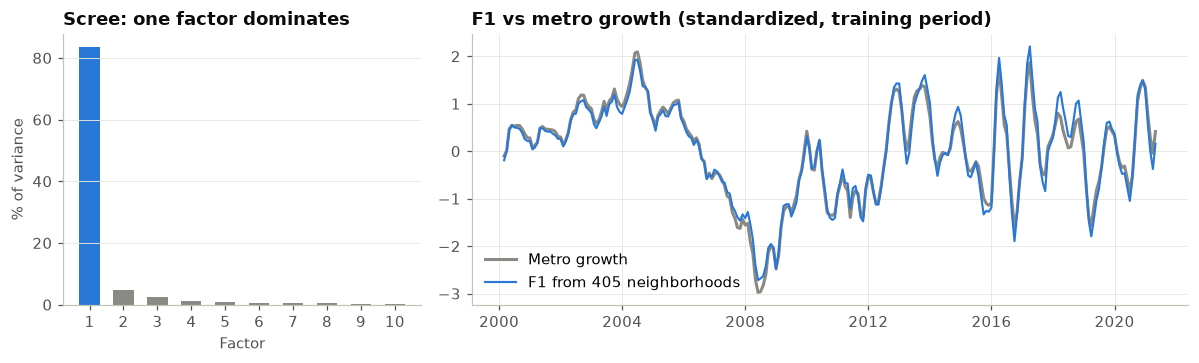

In [13]:
def panel_factors(G_upto, k=2):
    """Principal-component factors of standardized panel growth. Returns scores, loadings, mean, sd, shares."""
    Gc = G_upto.dropna()
    mu, sd = Gc.mean(), Gc.std()
    U, S, Vt = np.linalg.svd(((Gc - mu) / sd).values, full_matrices=False)
    F = pd.DataFrame(U[:, :k] * S[:k], index=Gc.index, columns=[f"F{i+1}" for i in range(k)])
    load = Vt[:k]
    if load[0].mean() < 0:                            # sign: F1 rises when neighborhoods rise
        F["F1"] *= -1; load[0] *= -1
    return F, load, mu, sd, S ** 2 / (S ** 2).sum()

F_tr, _, _, _, share = panel_factors(G.iloc[:N_TRAIN])
print("variance share of first 5 factors:", (100 * share[:5]).round(1))
print("corr(F1, metro growth):", round(F_tr.F1.corr(df.g), 3))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4), gridspec_kw={"width_ratios": [1, 2]})
axes[0].bar(range(1, 11), 100 * share[:10], color=[BLUE] + [GRAY] * 9, width=0.6)
axes[0].set_xticks(range(1, 11)); axes[0].set_xlabel("Factor"); axes[0].set_ylabel("% of variance")
axes[0].set_title("Scree: one factor dominates"); axes[0].grid(axis="x", visible=False)
std = lambda x: (x - x.mean()) / x.std()
axes[1].plot(F_tr.index, std(df.g.loc[F_tr.index]), color=GRAY, label="Metro growth")
axes[1].plot(F_tr.index, std(F_tr.F1), color=BLUE, lw=1.4, label=f"F1 from {Z.shape[1]} neighborhoods")
axes[1].set_title("F1 vs metro growth (standardized, training period)"); axes[1].legend()
fig.tight_layout(); fig.savefig(FIG / "08_factor_scree.png"); plt.show()

FVAR_K = 2
def f_fvar(d, h, **_):
    F, *_ = panel_factors(G.loc[:d.index[-1]], FVAR_K)
    v = pd.concat([d.g, F], axis=1).dropna()
    res = VAR(v).fit(maxlags=6, ic="aic")
    p = max(res.k_ar, 1)
    if res.k_ar == 0:
        res = VAR(v).fit(1)
    fc = res.forecast(v.values[-p:], h)
    return to_levels(d.logp.iloc[-1], fc[:, 0])

### Two more models from the course
**Prophet + COVID & rates** (Assignment 2A): the plain Prophet fits one smooth trend and reads the
2020-22 boom as a permanent trend. Following the Assignment 2 remedy, we mark the COVID boom as a
"holiday" and add the mortgage rate (lagged 24 months, so the next 24 months are already known) as
an extra regressor.

**Chronos** (slides 9a, Assignment 5): Amazon's pretrained time-series foundation model
(`amazon/chronos-bolt-base`). It forecasts zero-shot: it is never trained on our data, it only reads
the history up to each forecast origin.

In [14]:
COVID_BOOM = pd.date_range("2020-07-31", "2022-06-30", freq="ME")

def f_prophet_fix(d, h, **_):
    hol = pd.DataFrame({"holiday": "covid_boom", "ds": COVID_BOOM})
    m = Prophet(yearly_seasonality=False, weekly_seasonality=False, daily_seasonality=False, holidays=hol)
    m.add_regressor("rate_l24")
    path = pd.concat([d.rate, pd.Series(d.rate.iloc[-1], index=pd.date_range(
        d.index[-1] + pd.offsets.MonthEnd(1), periods=h, freq="ME"))])
    lag = path.shift(24)
    hist = pd.DataFrame({"ds": d.index, "y": d.logp.values, "rate_l24": lag.loc[d.index].values}).dropna()
    m.fit(hist)
    fut = pd.DataFrame({"ds": path.index[-h:], "rate_l24": lag.iloc[-h:].values})
    return m.predict(fut).yhat.values

from chronos import BaseChronosPipeline
CHRONOS = BaseChronosPipeline.from_pretrained("amazon/chronos-bolt-base", device_map="cpu", torch_dtype=torch.float32)

def f_chronos(d, h, **_):
    q, _m = CHRONOS.predict_quantiles(inputs=torch.tensor(d.zhvi.values, dtype=torch.float32),
                                      prediction_length=h, quantile_levels=[0.5])
    return np.log(q[0, :, 0].numpy())

MODELS = {
    "Naive drift": f_naive, "ARIMA": f_arima, "Holt (damped)": f_holt, "Prophet": f_prophet,
    "XGBoost": f_xgb, "LightGBM": f_lgbm, "LSTM": f_lstm, "GRU": f_gru,
    "Prophet + COVID & rates": f_prophet_fix, "Chronos (foundation model)": f_chronos,
    "VAR (growth + rate)": f_var, "Factor VAR (neighborhoods)": f_fvar, "ARIMAX": f_arimax_flat,
    "ARIMAX + jobs": f_arimax_jobs,
    "ARIMAX (realized rates)": f_arimax_realized,
}

Loading weights:   0%|          | 0/269 [00:00<?, ?it/s]

## 4. Blind test: forecast the whole 64-month test window from the train end

In [15]:
def metrics(actual, fc, last_actual):
    e = fc - actual
    da = np.mean(np.sign(np.diff(np.r_[last_actual, fc])) == np.sign(np.diff(np.r_[last_actual, actual])))
    return {"MAE": np.abs(e).mean(), "RMSE": np.sqrt((e ** 2).mean()),
            "MAPE %": 100 * np.mean(np.abs(e) / actual), "Dir. acc. %": 100 * da}

train, test = df.iloc[:N_TRAIN], df.iloc[N_TRAIN:]
blind_fc, blind = {}, {}
for name, f in MODELS.items():
    blind_fc[name] = np.exp(f(train, H, actual_rates=test.rate.values))
    blind[name] = metrics(test.zhvi.values, blind_fc[name], train.zhvi.iloc[-1])
blind = pd.DataFrame(blind).T.sort_values("MAPE %")
blind.style.format({"MAE": "${:,.0f}", "RMSE": "${:,.0f}", "MAPE %": "{:.1f}", "Dir. acc. %": "{:.0f}"})

10:11:41 - cmdstanpy - INFO - Chain [1] start processing


10:11:41 - cmdstanpy - INFO - Chain [1] done processing


10:11:42 - cmdstanpy - INFO - Chain [1] start processing


10:11:42 - cmdstanpy - INFO - Chain [1] done processing


/Users/thanapold/Desktop/MSBA Courses/437 Forecasting and Time Series Analysis/Final Project/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


,MAE,RMSE,MAPE %,Dir. acc. %
LightGBM,"$20,365","$25,872",2.2,55
ARIMAX (realized rates),"$25,845","$33,834",2.8,66
GRU,"$27,185","$36,994",3.0,66
ARIMAX + jobs,"$32,900","$38,662",3.6,66
ARIMAX,"$34,948","$46,536",3.8,66
Holt (damped),"$37,033","$41,154",4.0,66
Naive drift,"$40,259","$46,423",4.5,66
Prophet + COVID & rates,"$47,108","$53,517",5.3,62
Prophet,"$49,076","$55,419",5.5,64
ARIMA,"$58,112","$74,679",6.2,66


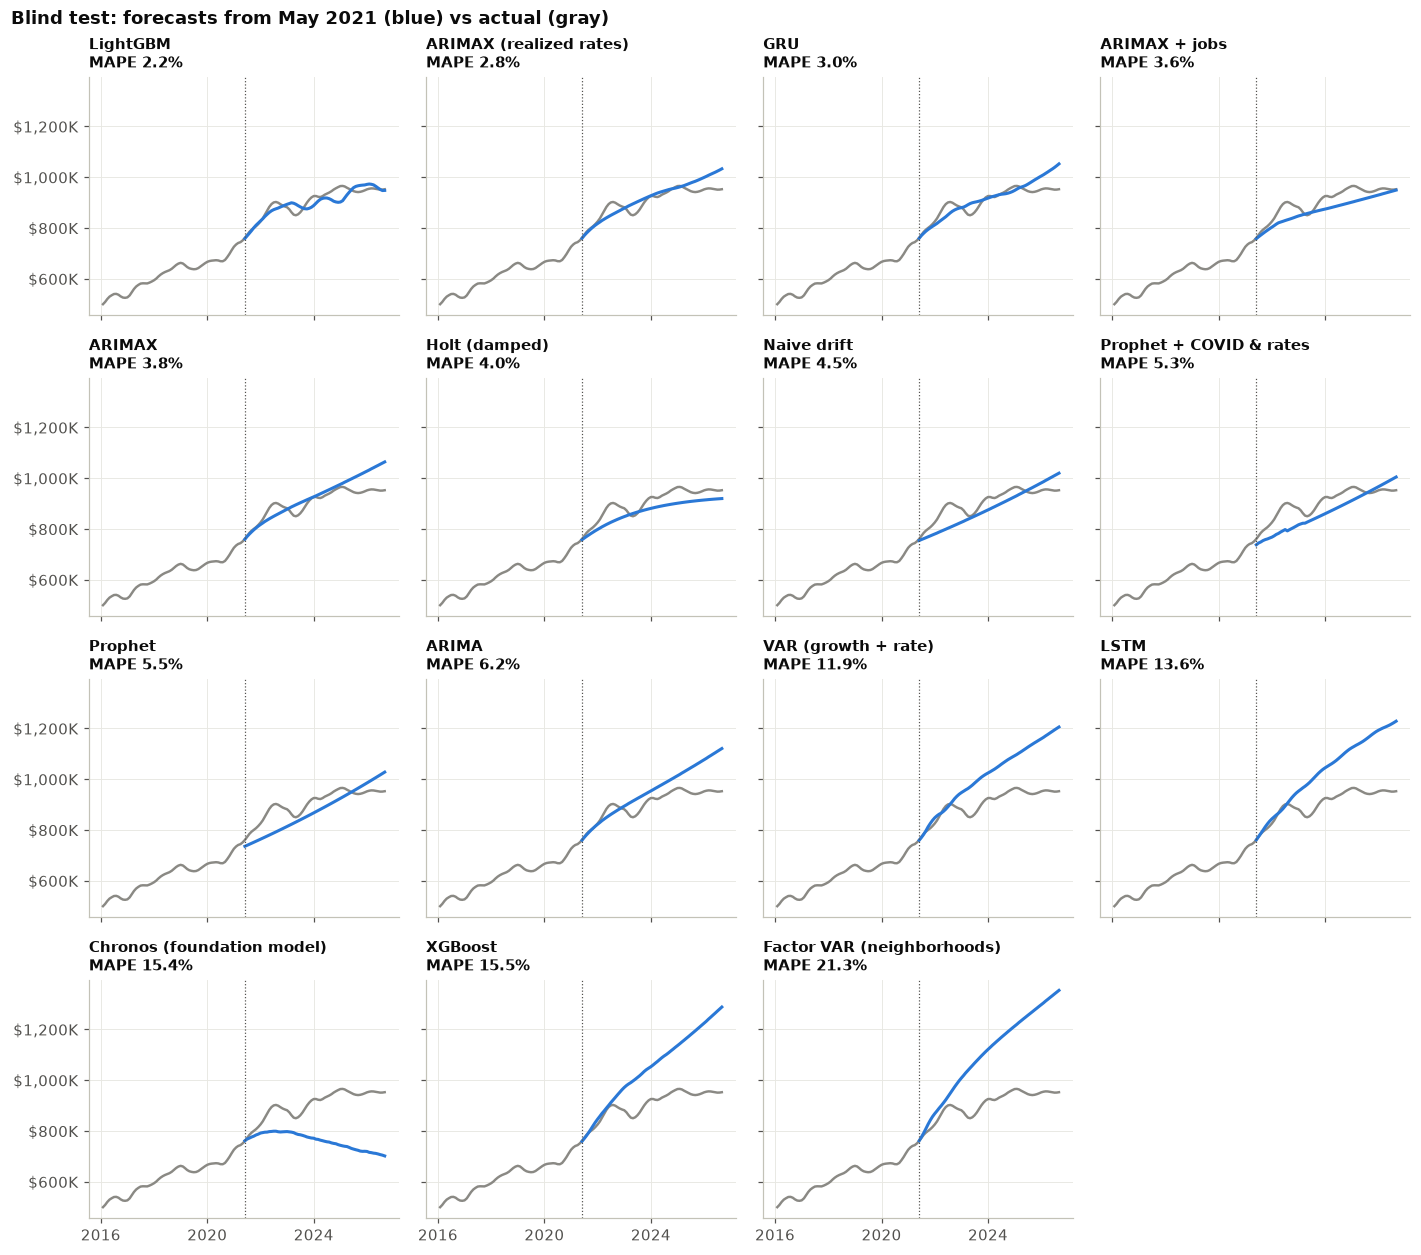

In [16]:
order = blind.index.tolist()
ncol = 4; nrow = int(np.ceil(len(order) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(13, 2.9 * nrow), sharex=True, sharey=True)
ctx = df.loc["2016":]
for ax, name in zip(axes.flat, order):
    ax.plot(ctx.index, ctx.zhvi, color=GRAY, lw=1.6)
    ax.plot(test.index, blind_fc[name], color=BLUE)
    ax.axvline(test.index[0], color=MUTED, lw=0.8, ls=":")
    ax.set_title(f"{name}\nMAPE {blind.loc[name, 'MAPE %']:.1f}%", fontsize=10)
    ax.yaxis.set_major_formatter(dollars)
    ax.xaxis.set_major_locator(mdates.YearLocator(4))
for ax in axes.flat[len(order):]:
    ax.set_visible(False)
fig.suptitle("Blind test: forecasts from May 2021 (blue) vs actual (gray)", x=0.01, ha="left",
             fontweight="bold", color=INK)
fig.tight_layout(); fig.savefig(FIG / "04_blind_test_grid.png"); plt.show()

## 5. Rolling-origin test: 12-month-ahead forecasts, refit every 3 months
This is the fairer comparison. Every model sees the same data at each origin and is scored on the
same horizons (1, 3, 6, 12 months ahead).

In [17]:
HORIZONS = (1, 3, 6, 12)
origins = list(range(N_TRAIN, N - 12 + 1, 3))
rows = []
for o in origins:
    d, fut = df.iloc[:o], df.iloc[o:o + 12]
    for name, f in MODELS.items():
        if name == "ARIMAX (realized rates)":      # identical to ARIMAX when 12 <= rate lag
            continue
        fc = np.exp(f(d, 12, actual_rates=fut.rate.values))
        ape = 100 * np.abs(fc - fut.zhvi.values) / fut.zhvi.values
        rows.append({"origin": df.index[o - 1], "model": name,
                     **{f"h{k}": ape[k - 1] for k in HORIZONS}, "avg 1-12": ape.mean()})
roll = pd.DataFrame(rows)
print(f"{len(origins)} origins, {roll.origin.min():%Y-%m} to {roll.origin.max():%Y-%m}")
roll_summary = roll.groupby("model")[[f"h{k}" for k in HORIZONS] + ["avg 1-12"]].mean().sort_values("avg 1-12")
roll_summary.round(2)

10:11:45 - cmdstanpy - INFO - Chain [1] start processing


10:11:45 - cmdstanpy - INFO - Chain [1] done processing


10:11:46 - cmdstanpy - INFO - Chain [1] start processing


10:11:46 - cmdstanpy - INFO - Chain [1] done processing


/Users/thanapold/Desktop/MSBA Courses/437 Forecasting and Time Series Analysis/Final Project/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


...

10:12:21 - cmdstanpy - INFO - Chain [1] start processing


10:12:21 - cmdstanpy - INFO - Chain [1] done processing


/Users/thanapold/Desktop/MSBA Courses/437 Forecasting and Time Series Analysis/Final Project/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


18 origins, 2021-04 to 2025-07


,h1,h3,h6,h12,avg 1-12
model,,,,,
ARIMAX,0.09,0.80,2.45,4.98,2.67
ARIMA,0.09,0.78,2.53,5.37,2.77
ARIMAX + jobs,0.12,0.94,2.63,5.12,2.81
VAR (growth + rate),0.14,0.94,2.56,5.74,2.93
LSTM,0.12,0.89,2.95,5.58,3.02
GRU,0.11,0.93,2.99,5.86,3.18
Naive drift,0.69,1.93,3.48,4.92,3.27
Holt (damped),0.29,1.15,3.04,6.34,3.39
Chronos (foundation model),0.69,1.61,3.44,6.13,3.56


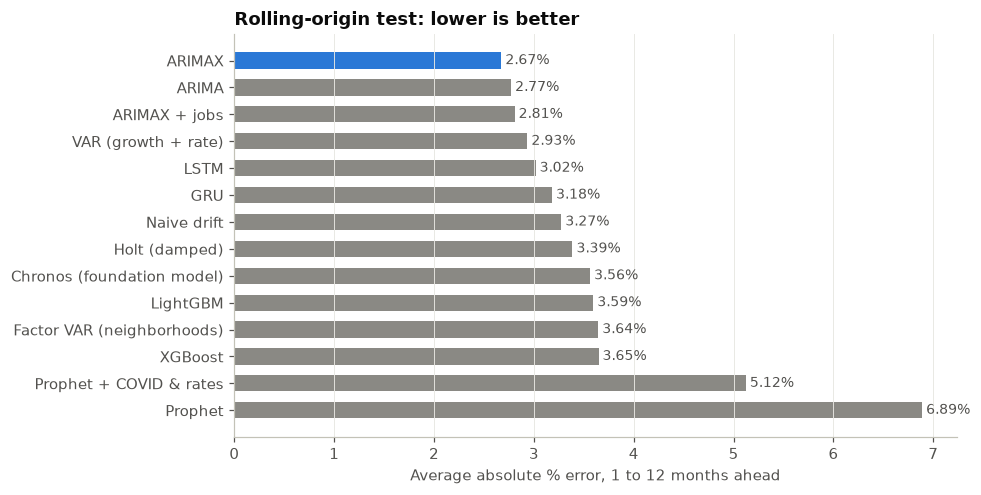

In [18]:
fig, ax = plt.subplots(figsize=(9, 4.6))
rs = roll_summary["avg 1-12"].sort_values(ascending=False)
colors = [BLUE if n == rs.idxmin() else GRAY for n in rs.index]
ax.barh(rs.index, rs.values, color=colors, height=0.6)
for y, v in enumerate(rs.values):
    ax.text(v, y, f" {v:.2f}%", va="center", color=MUTED, fontsize=9)
ax.set_xlabel("Average absolute % error, 1 to 12 months ahead")
ax.set_title("Rolling-origin test: lower is better")
ax.grid(axis="y", visible=False)
fig.tight_layout(); fig.savefig(FIG / "05_rolling_mape.png"); plt.show()

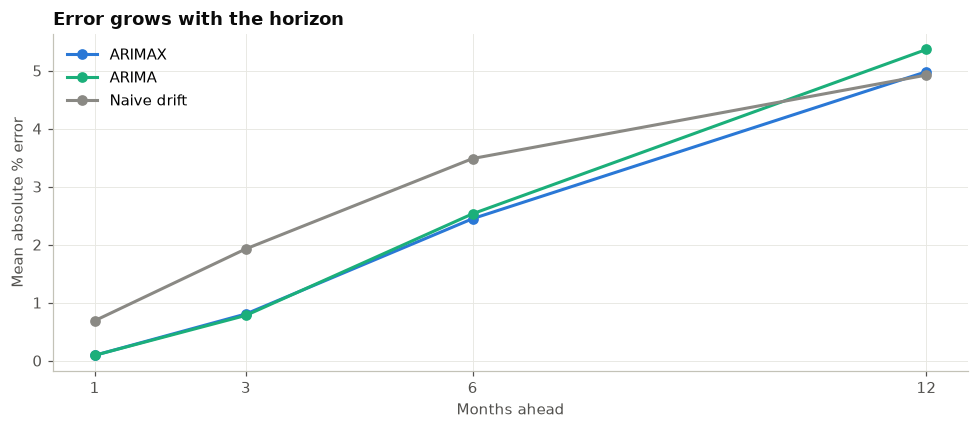

In [19]:
best_real = roll_summary.index[0]
fig, ax = plt.subplots(figsize=(9, 4))
for name, c in [(best_real, BLUE), ("ARIMA", AQUA), ("Naive drift", GRAY)]:
    if name in roll_summary.index:
        ax.plot(HORIZONS, roll_summary.loc[name, [f"h{k}" for k in HORIZONS]], marker="o", ms=6, color=c, label=name)
ax.set_xticks(HORIZONS); ax.set_xlabel("Months ahead"); ax.set_ylabel("Mean absolute % error")
ax.set_title("Error grows with the horizon"); ax.legend()
fig.tight_layout(); fig.savefig(FIG / "06_error_by_horizon.png"); plt.show()

## 5b. Can a chat LLM forecast? Claude, GPT and Gemini on the same 18 origins
We asked three LLMs (Claude Opus 5.5, GPT-5.5, Gemini 3.1 Pro) for 12-month forecasts at the same
18 origins, giving each only the data up to that origin and telling it not to run code. All 18
origins (2021-04 to 2025-07) fall before the models' training cutoffs, so an LLM could simply
remember what LA prices did next. We test that with three versions of each prompt:
- *named*: "Los Angeles metro, Zillow ZHVI", real dates and dollar values, plus the mortgage rate.
- *blind*: no place or dates, values rebased to 100, but the real mortgage rate (its 2022 spike
  still gives the dates away).
- *masked*: only the last 10 years of values, rebased so the latest month = 100, no rate.

If an LLM forecasts from the numbers, the three versions should score about the same. If it
recognizes the period, named and blind should be much better than masked.
Prompts come from `llm_prompts.py`; answers were collected with `llm_run_api.py` (GPT, Gemini) and
the Claude Code CLI (`claude -p --tools ""`, so Claude could not run code). The raw answers are in
`llm/answers/`, and this cell only scores them, so the notebook needs no API keys.

In [20]:
llm = pd.read_csv("llm/llm_forecasts.csv")
LLM_NAMES = {"claude-opus-5.5": "Claude Opus 5.5", "gpt-5.5": "GPT-5.5", "gemini-3.1-pro-preview": "Gemini 3.1 Pro"}
VARIANTS = ["named", "blind", "masked"]
llm["model"] = llm.model.map(LLM_NAMES)
llm_summary = (llm.groupby(["model", "variant"])[[f"h{k}" for k in HORIZONS] + ["avg 1-12"]].mean()
                  .reindex(pd.MultiIndex.from_product([LLM_NAMES.values(), VARIANTS])))
print(llm.groupby(["model", "variant"]).size().unstack().to_string())
pd.concat([llm_summary, roll_summary.loc[["ARIMAX", "ARIMA", "Naive drift"]]
              .set_index(pd.MultiIndex.from_tuples([(m, "statistical") for m in ["ARIMAX", "ARIMA", "Naive drift"]]))]).round(2)

variant          blind  masked  named
model                                
Claude Opus 5.5     18      18     18
GPT-5.5             18      18     18
Gemini 3.1 Pro      18      18     18


h1    h3    h6   h12  avg 1-12
Claude Opus 5.5 named        0.24  0.95  1.80  2.07      1.58
                blind        0.21  0.81  2.14  1.91      1.64
                masked       0.26  1.10  2.63  4.50      2.67
GPT-5.5         named        0.23  0.86  1.83  2.25      1.56
                blind        0.25  0.95  2.06  1.89      1.65
                masked       0.37  1.29  2.59  4.75      2.74
Gemini 3.1 Pro  named        0.20  0.75  1.66  2.07      1.43
                blind        0.30  1.14  2.47  2.95      2.09
                masked       0.30  1.37  3.18  4.80      3.00
ARIMAX          statistical  0.09  0.80  2.45  4.98      2.67
ARIMA           statistical  0.09  0.78  2.53  5.37      2.77
Naive drift     statistical  0.69  1.93  3.48  4.92      3.27

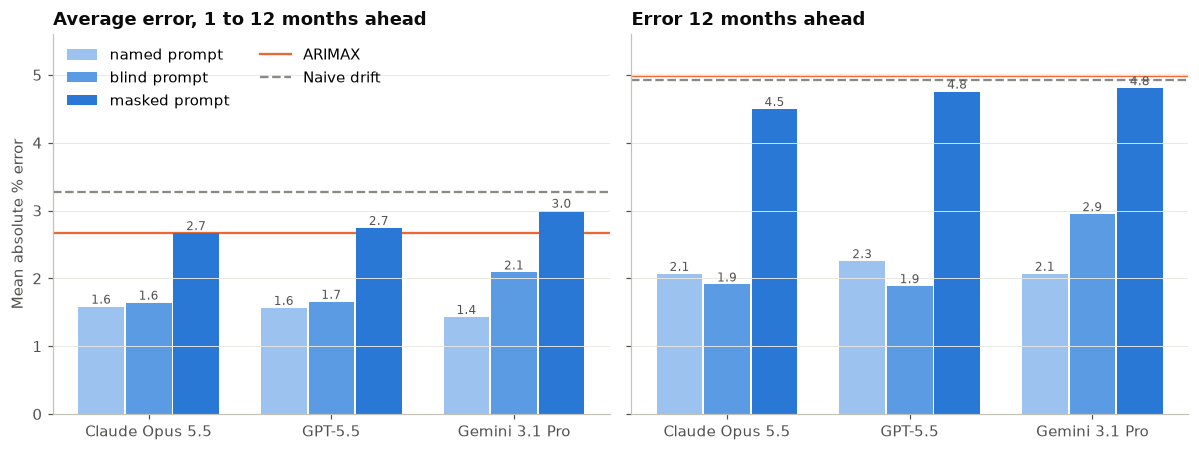

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
shades = {"named": "#9cc3ef", "blind": "#5a9be3", "masked": BLUE}
x = np.arange(len(LLM_NAMES))
for ax, col, title in [(axes[0], "avg 1-12", "Average error, 1 to 12 months ahead"),
                       (axes[1], "h12", "Error 12 months ahead")]:
    for i, v in enumerate(VARIANTS):
        vals = llm_summary.xs(v, level=1)[col].values
        ax.bar(x + (i - 1) * 0.26, vals, width=0.25, color=shades[v], label=v)
        for xi, val in zip(x + (i - 1) * 0.26, vals):
            ax.text(xi, val, f"{val:.1f}", ha="center", va="bottom", fontsize=8, color=MUTED)
    for name, c, ls in [("ARIMAX", ORANGE, "-"), ("Naive drift", GRAY, "--")]:
        ax.axhline(roll_summary.loc[name, col], color=c, ls=ls, lw=1.5, label=name, zorder=0)
    ax.set_xticks(x, LLM_NAMES.values()); ax.set_title(title); ax.grid(axis="x", visible=False)
axes[0].set_ylabel("Mean absolute % error"); axes[0].set_ylim(0, 5.6)
h, l = axes[0].get_legend_handles_labels()
axes[0].legend(h[2:] + h[:2], [f"{x} prompt" for x in l[2:]] + l[:2], loc="upper left", ncol=2)
fig.tight_layout(); fig.savefig(FIG / "06b_llm_test.png"); plt.show()

## 6. Forecast: September 2026 to August 2027
The best model from the rolling test, refit on all data. With the rate lag at 12 months or more,
ARIMAX's next 12 months depend only on rates already observed. ARIMA gives the uncertainty band.

In [22]:
H_OUT = 12
fut_idx = pd.date_range(df.index[-1] + pd.offsets.MonthEnd(1), periods=H_OUT, freq="ME")
print("Best model in rolling test:", best_real)

full_arima = pm.ARIMA(order=ARIMA_SPEC.order, with_intercept=ARIMA_SPEC.with_intercept,
                      suppress_warnings=True).fit(df.logp.values)
arima_fc, arima_ci = full_arima.predict(H_OUT, return_conf_int=True, alpha=0.2)
out = pd.DataFrame({"ARIMAX": np.exp(f_arimax_flat(df, H_OUT)),
                    "ARIMA": np.exp(arima_fc),
                    "ARIMA 80% low": np.exp(arima_ci[:, 0]), "ARIMA 80% high": np.exp(arima_ci[:, 1]),
                    "Naive drift": np.exp(f_naive(df, H_OUT))}, index=fut_idx)
if best_real not in out:
    out.insert(0, best_real, np.exp(MODELS[best_real](df, H_OUT, actual_rates=None)))
last = df.zhvi.iloc[-1]
print(f"Latest ZHVI ({df.index[-1]:%Y-%m}): ${last:,.0f}")
print((100 * (out.iloc[-1] / last - 1)).round(1).rename("12-month change %").to_string())
out.round(0)

Best model in rolling test: ARIMAX


Latest ZHVI (2026-08): $952,601
ARIMAX             4.8
ARIMA              4.6
ARIMA 80% low     -6.2
ARIMA 80% high    16.5
Naive drift        5.6


,ARIMAX,ARIMA,ARIMA 80% low,ARIMA 80% high,Naive drift
2026-09-30,956286.0,955444.0,952971.0,957924.0,956962.0
2026-10-31,960246.0,958455.0,950969.0,966000.0,961342.0
2026-11-30,964045.0,961652.0,946311.0,977240.0,965743.0
2026-12-31,967674.0,965013.0,940710.0,989944.0,970164.0
2027-01-31,971177.0,968520.0,934672.0,1003594.0,974605.0
2027-02-28,974854.0,972157.0,928469.0,1017901.0,979066.0
2027-03-31,978692.0,975909.0,922267.0,1032672.0,983548.0
2027-04-30,982622.0,979764.0,916171.0,1047772.0,988050.0
2027-05-31,986582.0,983712.0,910251.0,1063102.0,992573.0
2027-06-30,990511.0,987743.0,904549.0,1078588.0,997117.0


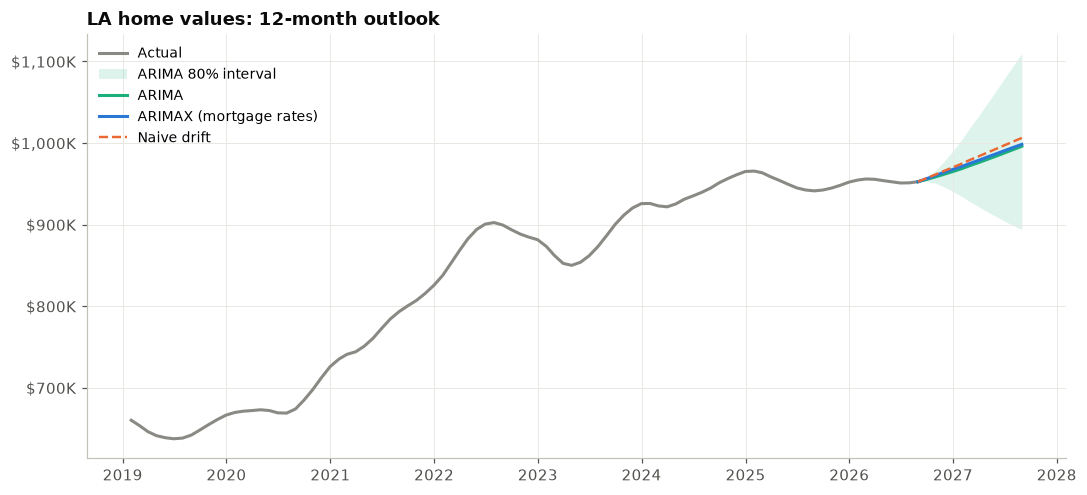

In [23]:
fig, ax = plt.subplots(figsize=(10, 4.6))
hist = df.loc["2019":]
ax.plot(hist.index, hist.zhvi, color=GRAY, label="Actual")
anchor = pd.DataFrame({c: [last] for c in out.columns}, index=[df.index[-1]])
plot_out = pd.concat([anchor, out])        # start every forecast line at the last actual point
ax.fill_between(plot_out.index, plot_out["ARIMA 80% low"], plot_out["ARIMA 80% high"], color=AQUA,
                alpha=0.15, lw=0, label="ARIMA 80% interval")
ax.plot(plot_out.index, plot_out["ARIMA"], color=AQUA, label="ARIMA")
ax.plot(plot_out.index, plot_out["ARIMAX"], color=BLUE, label="ARIMAX (mortgage rates)")
ax.plot(plot_out.index, plot_out["Naive drift"], color=ORANGE, ls="--", lw=1.6, label="Naive drift")
ax.yaxis.set_major_formatter(dollars)
ax.set_title("LA home values: 12-month outlook")
ax.legend(loc="upper left", fontsize=9)
fig.tight_layout(); fig.savefig(FIG / "07_outlook.png"); plt.show()

## 7. Neighborhoods: what the metro average hides
### 7a. The 2022 rate shock, neighborhood by neighborhood
For each neighborhood: the change from its 2022 peak to its lowest point between mid-2022 and
2023 (drawdown), and from that peak to today. Uses every neighborhood with data since 2020.

In [24]:
peak22 = ZA.loc["2022"].max()
trough = ZA.loc["2022-07":"2023-12"].min()
price21 = ZA.loc["2021-12-31"]
nbA = nb_info.loc[ZA.columns]                          # neighborhoods with data since 2020
shock = pd.DataFrame({
    "name": nbA.label, "county": nbA.CountyName,
    "value_dec2021": price21,
    "boom_2020_22_%": 100 * (peak22 / ZA.loc["2020-02-29"] - 1),
    "drawdown_%": 100 * (trough / peak22 - 1),
    "vs_2022_peak_now_%": 100 * (ZA.iloc[-1] / peak22 - 1),
})
shock["price_quintile"] = pd.qcut(shock.value_dec2021, 5, labels=["Q1 cheapest", "Q2", "Q3", "Q4", "Q5 priciest"])
by_q = shock.groupby("price_quintile", observed=True)[["value_dec2021", "boom_2020_22_%", "drawdown_%", "vs_2022_peak_now_%"]].median()
print(by_q.round(1).to_string()); print()
print(shock.groupby("county")[["boom_2020_22_%", "drawdown_%", "vs_2022_peak_now_%"]].median().round(1).to_string())
for c in ["Los Angeles County", "Orange County"]:
    s_ = shock[shock.county == c]
    print(f"corr(log price, drawdown) {c}: {np.log(s_.value_dec2021).corr(s_['drawdown_%']):.2f}")
print("below 2022 peak today:", (shock["vs_2022_peak_now_%"] < 0).sum(), "of", len(shock))

                value_dec2021  boom_2020_22_%  drawdown_%  vs_2022_peak_now_%
price_quintile                                                               
Q1 cheapest          603873.3            32.5        -4.6                 2.9
Q2                   746007.1            33.8        -5.2                 4.0
Q3                   924971.5            34.8        -5.8                 6.5
Q4                  1194681.6            37.9        -6.6                 4.6
Q5 priciest         1883855.4            32.1        -6.7                 3.8

                    boom_2020_22_%  drawdown_%  vs_2022_peak_now_%
county                                                            
Los Angeles County            32.5        -6.3                 1.2
Orange County                 37.9        -4.3                15.3
corr(log price, drawdown) Los Angeles County: -0.45
corr(log price, drawdown) Orange County: 0.10
below 2022 peak today: 152 of 496


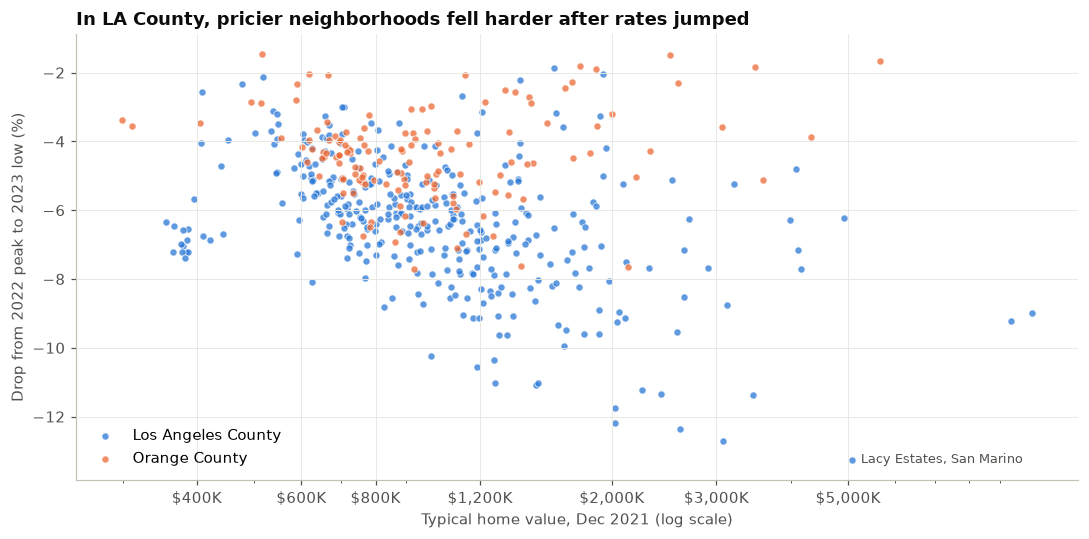

In [25]:
fig, ax = plt.subplots(figsize=(10, 5))
for county, c in [("Los Angeles County", BLUE), ("Orange County", ORANGE)]:
    m = shock.county == county
    ax.scatter(shock.value_dec2021[m], shock["drawdown_%"][m], s=22, color=c, alpha=0.75,
               edgecolor="white", linewidth=0.6, label=county)
worst = shock.sort_values("drawdown_%").head(1)        # label only the extreme; names are in the report
for n_ in worst.index:
    ax.annotate(shock.name[n_], (shock.value_dec2021[n_], shock["drawdown_%"][n_]),
                xytext=(6, -2), textcoords="offset points", fontsize=8.5, color=MUTED)
ax.set_xscale("log"); ax.xaxis.set_major_formatter(dollars)
ax.xaxis.set_minor_formatter(plt.NullFormatter())
ax.set_xticks([400e3, 600e3, 800e3, 1.2e6, 2e6, 3e6, 5e6])
ax.set_xlabel("Typical home value, Dec 2021 (log scale)"); ax.set_ylabel("Drop from 2022 peak to 2023 low (%)")
ax.set_title("In LA County, pricier neighborhoods fell harder after rates jumped"); ax.legend(loc="lower left")
fig.tight_layout(); fig.savefig(FIG / "09_nbhd_drawdown.png"); plt.show()

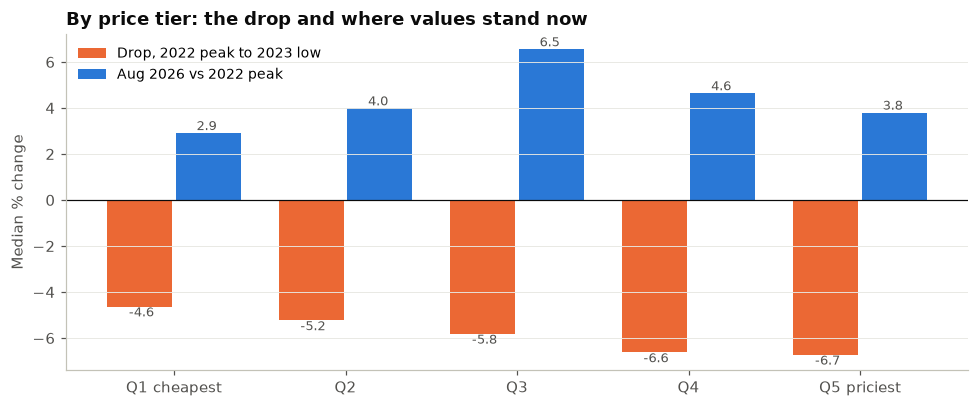

In [26]:
fig, ax = plt.subplots(figsize=(9, 3.8))
x = np.arange(len(by_q)); w = 0.38
ax.bar(x - w / 2 - 0.01, by_q["drawdown_%"], w, color=ORANGE, label="Drop, 2022 peak to 2023 low")
ax.bar(x + w / 2 + 0.01, by_q["vs_2022_peak_now_%"], w, color=BLUE, label="Aug 2026 vs 2022 peak")
for i, (a, b) in enumerate(zip(by_q["drawdown_%"], by_q["vs_2022_peak_now_%"])):
    ax.text(i - w / 2, a, f"{a:.1f}", ha="center", va="top" if a < 0 else "bottom", fontsize=8.5, color=MUTED)
    ax.text(i + w / 2, b, f"{b:.1f}", ha="center", va="top" if b < 0 else "bottom", fontsize=8.5, color=MUTED)
ax.axhline(0, color=INK, lw=0.8)
ax.set_xticks(x, by_q.index); ax.set_ylabel("Median % change")
ax.set_title("By price tier: the drop and where values stand now"); ax.legend(fontsize=9)
ax.grid(axis="x", visible=False)
fig.tight_layout(); fig.savefig(FIG / "10_tier_drawdown.png"); plt.show()

### 7b. Forecasting every neighborhood: does a shared factor beat separate models?
Five yearly origins (Apr 2021 to Apr 2025), 12 months ahead, scored on every neighborhood with
full 2000-2026 history.
- *Naive drift*: each neighborhood's own average growth.
- *ARIMA per neighborhood*: the metro ARIMA order, refit on each neighborhood.
- *Factor model*: forecast the two common factors with a VAR and map them back to every
  neighborhood through its loadings.

In [27]:
def nb_naive(Zd, Gd, h):
    return Zd.iloc[-1].values * np.exp(np.outer(np.arange(1, h + 1), Gd.mean().values) / 100)

def nb_arima(Zd, Gd, h):
    out = []
    for c in Zd.columns:
        m = pm.ARIMA(order=ARIMA_SPEC.order, with_intercept=ARIMA_SPEC.with_intercept,
                     suppress_warnings=True).fit(np.log(Zd[c].values))
        out.append(np.exp(m.predict(h)))
    return np.column_stack(out)

def nb_factor(Zd, Gd, h, k=FVAR_K):
    F, load, mu, sd, _ = panel_factors(Gd, k)
    res = VAR(F).fit(maxlags=6, ic="aic")
    p = max(res.k_ar, 1)
    if res.k_ar == 0:
        res = VAR(F).fit(1)
    F_fc = res.forecast(F.values[-p:], h)
    g_fc = mu.values + sd.values * (F_fc @ load)      # h x neighborhoods
    return Zd.iloc[-1].values * np.exp(np.cumsum(g_fc, axis=0) / 100)

NB_METHODS = {"Naive drift": nb_naive, "ARIMA per neighborhood": nb_arima, "Factor model": nb_factor}
nb_origins = list(range(N_TRAIN, N - 12 + 1, 12))
nrows = []
for o in nb_origins:
    Zd, Gd, actual = Z.iloc[:o], G.iloc[:o], Z.iloc[o:o + 12].values
    for name, f in NB_METHODS.items():
        ape = 100 * np.abs(f(Zd, Gd, 12) - actual) / actual            # 12 x neighborhoods
        nrows.append(pd.DataFrame({"origin": df.index[o - 1], "method": name, "nbhd": Zd.columns,
                                   "h12": ape[-1], "avg 1-12": ape.mean(axis=0)}))
nres = pd.concat(nrows)
nb_summary = nres.groupby("method")[["avg 1-12", "h12"]].mean().sort_values("avg 1-12")
wins = (nres.pivot_table(index=["origin", "nbhd"], columns="method", values="avg 1-12")
            .idxmin(axis=1).value_counts(normalize=True).mul(100).round(0))
nb_summary["% of cases best"] = wins
print(f"{len(nb_origins)} origins x {Z.shape[1]} neighborhoods")
nb_summary.round(2)

/Users/thanapold/Desktop/MSBA Courses/437 Forecasting and Time Series Analysis/Final Project/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


/Users/thanapold/Desktop/MSBA Courses/437 Forecasting and Time Series Analysis/Final Project/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


/Users/thanapold/Desktop/MSBA Courses/437 Forecasting and Time Series Analysis/Final Project/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


/Users/thanapold/Desktop/MSBA Courses/437 Forecasting and Time Series Analysis/Final Project/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


5 origins x 405 neighborhoods


/Users/thanapold/Desktop/MSBA Courses/437 Forecasting and Time Series Analysis/Final Project/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


,avg 1-12,h12,% of cases best
method,,,
ARIMA per neighborhood,2.84,5.87,41.0
Naive drift,3.53,6.89,28.0
Factor model,4.08,8.20,31.0


### 7c. Neighborhood outlook, September 2026 to August 2027
The best method from 7b, refit on all data.

In [28]:
best_nb = nb_summary.index[0]
nfc = NB_METHODS[best_nb](Z, G, 12)
nb_out = shock.loc[Z.columns, ["name", "county", "drawdown_%", "vs_2022_peak_now_%"]].copy()
nb_out["value_aug2026"] = Z.iloc[-1]
nb_out["forecast_aug2027"] = nfc[-1]
nb_out["forecast_12m_%"] = 100 * (nfc[-1] / Z.iloc[-1].values - 1)
print(f"method: {best_nb}")
print(nb_out["forecast_12m_%"].describe().round(2).to_string())
print(nb_out.groupby("county")["forecast_12m_%"].median().round(2).to_string())

method: ARIMA per neighborhood
count    405.00
mean       5.02
std        2.34
min       -2.05
25%        3.64
50%        5.06
75%        6.54
max       11.96
county
Los Angeles County    4.75
Orange County         6.52


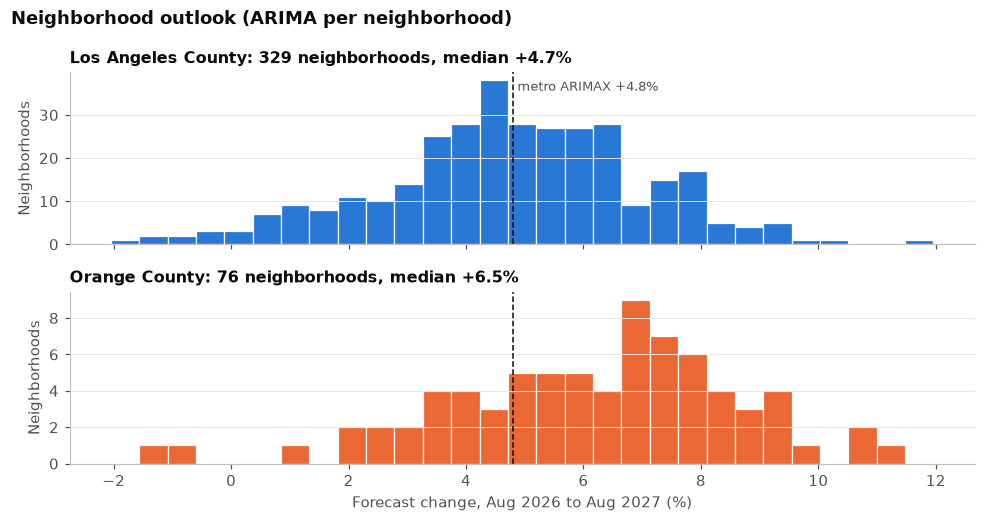

In [29]:
metro_chg = 100 * (out["ARIMAX"].iloc[-1] / last - 1)
bins = np.linspace(nb_out["forecast_12m_%"].min(), nb_out["forecast_12m_%"].max(), 30)
fig, axes = plt.subplots(2, 1, figsize=(9, 4.8), sharex=True)
for ax, (county, c) in zip(axes, [("Los Angeles County", BLUE), ("Orange County", ORANGE)]):
    vals = nb_out.loc[nb_out.county == county, "forecast_12m_%"]
    ax.hist(vals, bins=bins, color=c, edgecolor="white", linewidth=0.8)
    ax.axvline(metro_chg, color=INK, lw=1, ls="--")
    ax.set_title(f"{county}: {len(vals)} neighborhoods, median {vals.median():+.1f}%", fontsize=10.5)
    ax.set_ylabel("Neighborhoods"); ax.grid(axis="x", visible=False)
axes[0].text(metro_chg, axes[0].get_ylim()[1] * 0.95, f" metro ARIMAX {metro_chg:+.1f}%", fontsize=8.5, color=MUTED, va="top")
axes[1].set_xlabel("Forecast change, Aug 2026 to Aug 2027 (%)")
fig.suptitle(f"Neighborhood outlook ({best_nb})", x=0.01, ha="left", fontweight="bold", color=INK)
fig.tight_layout(); fig.savefig(FIG / "12_nbhd_outlook.png"); plt.show()

### 7d. Which neighborhoods are rising and which are falling right now?
Trend = change over the last 12 months (Aug 2025 to Aug 2026): *rising* above +2%, *falling*
below -2%, *flat* in between. The 3-month change (annualized) shows the latest momentum.
Map positions are neighborhood centroids geocoded from OpenStreetMap (Nominatim).

In [30]:
trend = pd.DataFrame({
    "name": nbA.label, "city": nbA.City, "county": nbA.CountyName,
    "value_aug2026": ZA.iloc[-1],
    "chg_12m_%": 100 * (ZA.iloc[-1] / ZA.iloc[-13] - 1),
    "chg_3m_ann_%": 100 * ((ZA.iloc[-1] / ZA.iloc[-4]) ** 4 - 1),
    "forecast_12m_%": nb_out["forecast_12m_%"],
}).join(nb_xy, how="left")
trend["direction"] = np.select([trend["chg_12m_%"] > 2, trend["chg_12m_%"] < -2], ["Rising", "Falling"], "Flat")
print(trend.direction.value_counts().to_string()); print()
print(pd.crosstab(trend.county, trend.direction).to_string()); print()
la_city = trend[trend.city == "Los Angeles"]
print("City of LA:", la_city.direction.value_counts().to_dict())
cols = ["name", "county", "value_aug2026", "chg_12m_%", "chg_3m_ann_%", "forecast_12m_%"]
print("\nRising most:\n", trend.nlargest(12, "chg_12m_%")[cols].round(1).to_string())
print("\nFalling most:\n", trend.nsmallest(12, "chg_12m_%")[cols].round(1).to_string())

direction
Rising     220
Flat       216
Falling     60

direction           Falling  Flat  Rising
county                                   
Los Angeles County       51   174     133
Orange County             9    42      87

City of LA: {'Flat': 56, 'Rising': 22, 'Falling': 18}

Rising most:
                                           name              county  value_aug2026  chg_12m_%  chg_3m_ann_%  forecast_12m_%
RegionID                                                                                                                  
800824    Beverly Hills Gateway, Beverly Hills  Los Angeles County     11517309.3       17.6          23.5            12.0
800825                The Flats, Beverly Hills  Los Angeles County     10345590.5       16.8          18.8             9.5
763779          North of Montana, Santa Monica  Los Angeles County      4955297.0       15.9          12.4             9.3
16250                     Surfside, Seal Beach       Orange County      2684890.1       14.

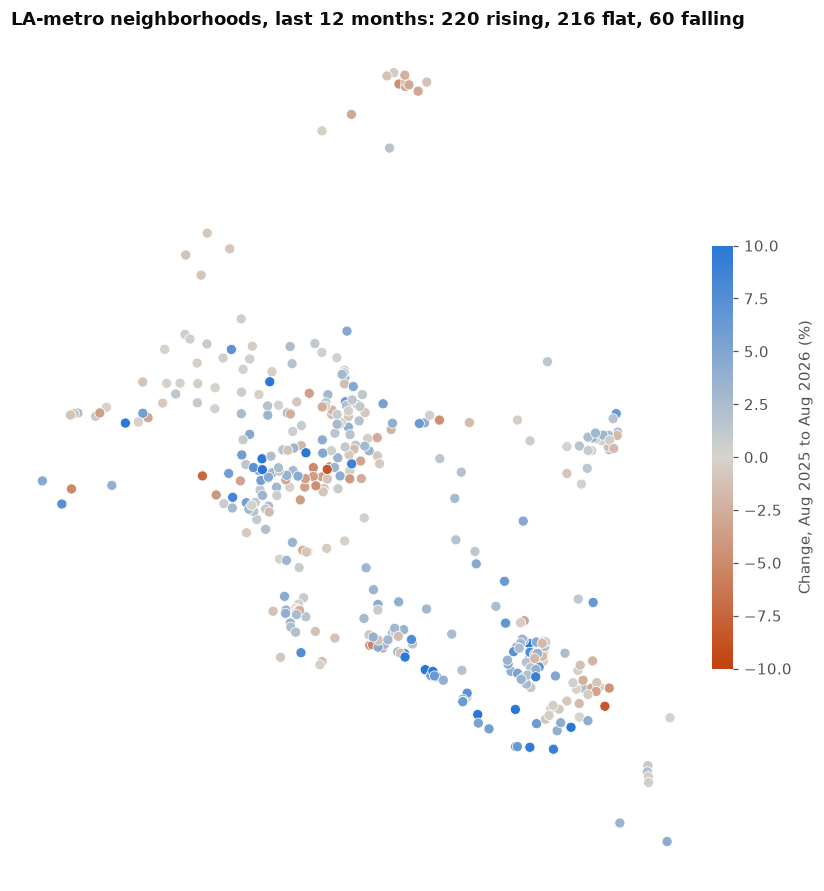

mapped 394 of 496 neighborhoods


In [31]:
RED, NEUTRAL = "#c2410c", "#d6d3cc"
lim = np.ceil(trend["chg_12m_%"].abs().quantile(0.97))
cmap = plt.matplotlib.colors.LinearSegmentedColormap.from_list("div", [RED, NEUTRAL, BLUE])
mp = trend.dropna(subset=["lat", "lon"])
fig, ax = plt.subplots(figsize=(10, 8.2))
ax.grid(False)
sc = ax.scatter(mp.lon, mp.lat, c=mp["chg_12m_%"].clip(-lim, lim), cmap=cmap, vmin=-lim, vmax=lim,
                s=44, edgecolor="white", linewidth=0.5)
ax.set_aspect(1 / np.cos(np.deg2rad(mp.lat.mean())))
# no point labels: central LA is too dense; the ranked chart (fig 14) names the movers
ax.set_xticks([]); ax.set_yticks([])
for sp in ax.spines.values(): sp.set_visible(False)
cb = fig.colorbar(sc, ax=ax, shrink=0.5, pad=0.01)
cb.set_label("Change, Aug 2025 to Aug 2026 (%)", color=MUTED); cb.outline.set_visible(False)
n = trend.direction.value_counts()
ax.set_title(f"LA-metro neighborhoods, last 12 months: {n.get('Rising', 0)} rising, "
             f"{n.get('Flat', 0)} flat, {n.get('Falling', 0)} falling")
fig.tight_layout(); fig.savefig(FIG / "13_nbhd_trend_map.png"); plt.show()
print(f"mapped {len(mp)} of {len(trend)} neighborhoods")

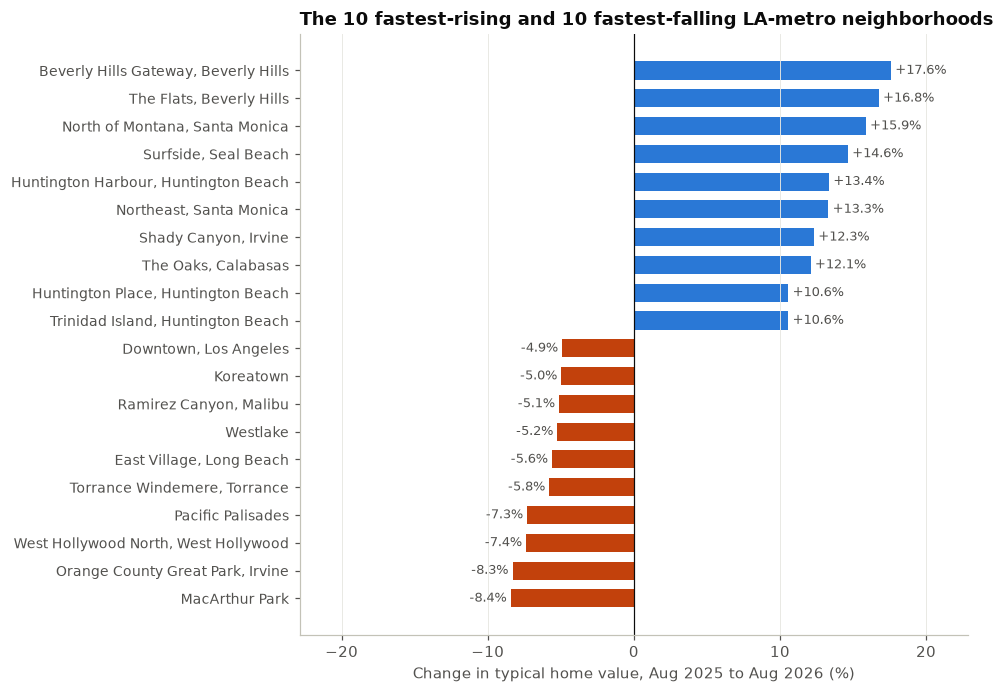

In [32]:
top = pd.concat([trend.nlargest(10, "chg_12m_%"), trend.nsmallest(10, "chg_12m_%").iloc[::-1]])
fig, ax = plt.subplots(figsize=(9, 6.4))
y = np.arange(len(top))[::-1]
ax.barh(y, top["chg_12m_%"], color=[BLUE if v > 0 else RED for v in top["chg_12m_%"]], height=0.65)
for yi, v in zip(y, top["chg_12m_%"]):
    ax.text(v + (0.3 if v > 0 else -0.3), yi, f"{v:+.1f}%", va="center", ha="left" if v > 0 else "right",
            fontsize=8.5, color=MUTED)
ax.set_yticks(y, top["name"], fontsize=9)
ax.axvline(0, color=INK, lw=0.8)
span = top["chg_12m_%"].abs().max()
ax.set_xlim(-span * 1.3, span * 1.3)
ax.set_xlabel("Change in typical home value, Aug 2025 to Aug 2026 (%)")
ax.set_title("The 10 fastest-rising and 10 fastest-falling LA-metro neighborhoods")
ax.grid(axis="y", visible=False)
fig.tight_layout(); fig.savefig(FIG / "14_nbhd_trend_rank.png"); plt.show()

## 9. Applying the course toolkit
Methods from the lectures and assignments, each asking one question of our data.

### 9a. Do mortgage rates Granger-cause LA home values? Impulse response (slides 6, Assignment 4)

/Users/thanapold/Desktop/MSBA Courses/437 Forecasting and Time Series Analysis/Final Project/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


Rates -> home growth:  F = 1.80, p = 0.0516
Home growth -> rates:  F = 0.94, p = 0.5057


 month  cum_%   lo90  hi90
     6  -1.63  -3.39  0.19
    12  -4.49  -8.25 -0.73
    18  -7.40 -12.89 -1.36
    24  -9.21 -15.71 -1.66
    36 -11.19 -19.00 -1.74


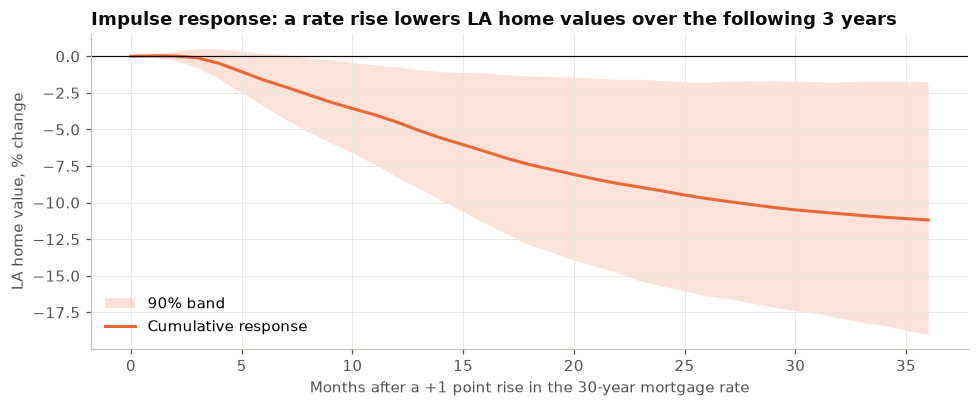

In [33]:
v_full = df[["g"]].assign(dr=df.rate.diff()).dropna()
var_full = VAR(v_full).fit(VAR_LAGS)
gc_rate = var_full.test_causality("g", ["dr"], kind="f")
gc_home = var_full.test_causality("dr", ["g"], kind="f")
print(f"Rates -> home growth:  F = {gc_rate.test_statistic:.2f}, p = {gc_rate.pvalue:.4f}")
print(f"Home growth -> rates:  F = {gc_home.test_statistic:.2f}, p = {gc_home.pvalue:.4f}")

IRF_H = 36
irf = var_full.irf(IRF_H)
cum = irf.cum_effects[:, 0, 1]                        # cumulative response of growth (%) to a +1 pt rate change
lo_b, hi_b = irf.cum_errband_mc(orth=False, repl=500, signif=0.10, seed=0)
irf_tbl = pd.DataFrame({"month": range(IRF_H + 1), "cum_%": cum, "lo90": lo_b[:, 0, 1], "hi90": hi_b[:, 0, 1]})
print(irf_tbl.iloc[[6, 12, 18, 24, 36]].round(2).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.fill_between(irf_tbl.month, irf_tbl.lo90, irf_tbl.hi90, color=ORANGE, alpha=0.18, lw=0, label="90% band")
ax.plot(irf_tbl.month, irf_tbl["cum_%"], color=ORANGE, label="Cumulative response")
ax.axhline(0, color=INK, lw=0.8)
ax.set_xlabel("Months after a +1 point rise in the 30-year mortgage rate")
ax.set_ylabel("LA home value, % change")
ax.set_title("Impulse response: a rate rise lowers LA home values over the following 3 years")
ax.legend(loc="lower left")
fig.tight_layout(); fig.savefig(FIG / "15_irf_rate_shock.png"); plt.show()

### 9a-2. Do payroll jobs drive LA home values? (slides 6, Assignment 4)
Add 12-month payroll job growth (LA + Orange County) to the VAR. Three questions: do jobs
Granger-cause home values, how big is the response to a jobs shock, and does the rate effect
survive once jobs are in the model?

3-variable VAR, 12 lags
                                      p-value
jobs -> home growth                    0.0540
home growth -> jobs                    0.7039
rates -> home growth (jobs in model)   0.1430


/Users/thanapold/Desktop/MSBA Courses/437 Forecasting and Time Series Analysis/Final Project/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/Users/thanapold/Desktop/MSBA Courses/437 Forecasting and Time Series Analysis/Final Project/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


 month  jobs_cum_%  jobs_lo90  jobs_hi90  rate_cum_%
     6       -0.15      -0.34       0.06       -1.35
    12       -0.29      -0.65       0.12       -4.01
    24       -0.76      -1.51      -0.04       -9.33
    36       -0.95      -1.80      -0.13      -12.58
                        lags  p jobs -> home  p rates -> home  jobs shock, 24 mo %  rate shock, 24 mo %
2000-2026               11.0           0.039            0.055               -0.600               -8.956
2000-2019               11.0           0.480            0.072               -1.174              -10.695
drop Mar 2020-Dec 2021   9.0           0.082            0.256               -2.887               -5.323
                    corr, jobs lead 0 mo  corr, jobs lead 6 mo  corr, jobs lead 12 mo  job growth, last 12 mo %  home growth, last 12 mo %
Los Angeles County                  0.28                  0.11                  -0.04                      0.74                       1.06
Orange County                       0.44 

/Users/thanapold/Desktop/MSBA Courses/437 Forecasting and Time Series Analysis/Final Project/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/Users/thanapold/Desktop/MSBA Courses/437 Forecasting and Time Series Analysis/Final Project/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/Users/thanapold/Desktop/MSBA Courses/437 Forecasting and Time Series Analysis/Final Project/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/Users/thanapold/Desktop/MSBA Courses/437 Forecasting and Time Series Analysis/Final Project/.venv/lib/python3.13/site-packages

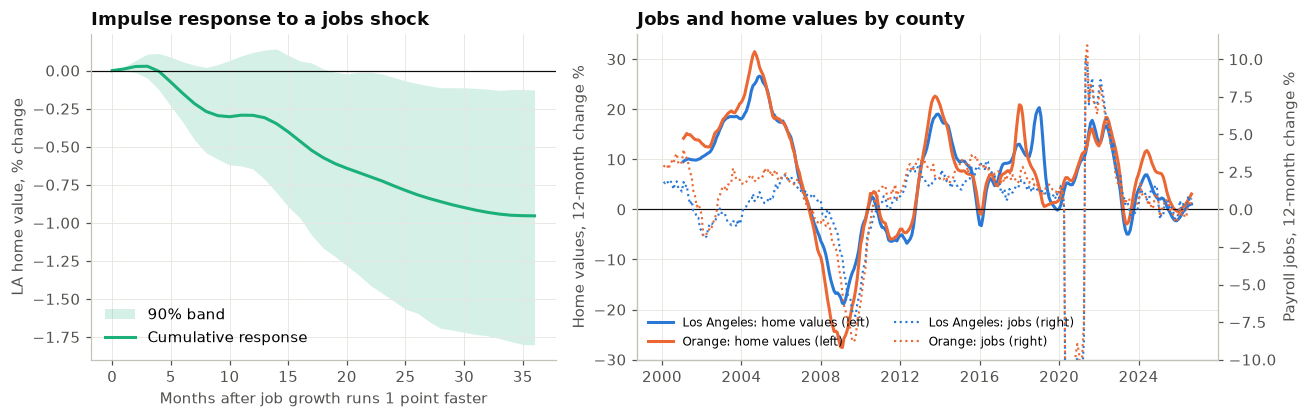

In [34]:
v3 = df[["g"]].assign(dr=df.rate.diff(), jg=df.jg).dropna()
VAR3_LAGS = VAR(v3.loc[:train_end]).select_order(maxlags=12).aic
var3 = VAR(v3).fit(VAR3_LAGS)
jobs_gc = pd.DataFrame({
    "jobs -> home growth": var3.test_causality("g", ["jg"], kind="f").pvalue,
    "home growth -> jobs": var3.test_causality("jg", ["g"], kind="f").pvalue,
    "rates -> home growth (jobs in model)": var3.test_causality("g", ["dr"], kind="f").pvalue,
}, index=["p-value"]).T
print(f"3-variable VAR, {VAR3_LAGS} lags"); print(jobs_gc.round(4).to_string())

irf3 = var3.irf(IRF_H)
lo3, hi3 = irf3.cum_errband_mc(orth=False, repl=500, signif=0.10, seed=0)
J = list(v3.columns).index("jg"); R = list(v3.columns).index("dr")
irf_jobs = pd.DataFrame({"month": range(IRF_H + 1),
                         "jobs_cum_%": irf3.cum_effects[:, 0, J], "jobs_lo90": lo3[:, 0, J], "jobs_hi90": hi3[:, 0, J],
                         "rate_cum_%": irf3.cum_effects[:, 0, R]})
print(irf_jobs.iloc[[6, 12, 24, 36]].round(2).to_string(index=False))

# robustness: LA payroll jobs fell 17% and then rebounded 10% in 2020-21, far outside the
# -7.5% to +3.1% range of 2000-2019. Does the jobs signal survive without those months?
def var3_check(sub):
    lags = VAR(sub).select_order(maxlags=12).aic
    v = VAR(sub).fit(lags)
    ce = v.irf(IRF_H).cum_effects
    return {"lags": lags, "p jobs -> home": v.test_causality("g", ["jg"], kind="f").pvalue,
            "p rates -> home": v.test_causality("g", ["dr"], kind="f").pvalue,
            "jobs shock, 24 mo %": ce[24, 0, J], "rate shock, 24 mo %": ce[24, 0, R]}
jobs_robust = pd.DataFrame({"2000-2026": var3_check(v3), "2000-2019": var3_check(v3.loc[:"2019-12"]),
                            "drop Mar 2020-Dec 2021": var3_check(v3.drop(v3.loc["2020-03":"2021-12"].index))}).T
print(jobs_robust.round(3).to_string())

# county view: job growth vs the median neighborhood's 12-month home value growth, by county
county_of = nb_info.loc[Z.columns, "CountyName"]
home_c = pd.DataFrame({c: (100 * (Z / Z.shift(12) - 1)).loc[:, county_of == c].median(axis=1) for c in jobs_c})
jobs_cg = (100 * np.log(jobs_c).diff(12)).reindex(df.index)
county_jobs = pd.DataFrame({c: {f"corr, jobs lead {k} mo": home_c[c].corr(jobs_cg[c].shift(k)) for k in (0, 6, 12)}
                            for c in jobs_c}).T
county_jobs["job growth, last 12 mo %"] = jobs_cg.iloc[-1]
county_jobs["home growth, last 12 mo %"] = home_c.iloc[-1]
print(county_jobs.round(2).to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 3.9), gridspec_kw={"width_ratios": [1, 1.25]})
ax = axes[0]
ax.fill_between(irf_jobs.month, irf_jobs.jobs_lo90, irf_jobs.jobs_hi90, color=AQUA, alpha=0.18, lw=0, label="90% band")
ax.plot(irf_jobs.month, irf_jobs["jobs_cum_%"], color=AQUA, label="Cumulative response")
ax.axhline(0, color=INK, lw=0.8)
ax.set_xlabel("Months after job growth runs 1 point faster"); ax.set_ylabel("LA home value, % change")
ax.set_title("Impulse response to a jobs shock"); ax.legend(loc="lower left")
ax = axes[1]
axj = ax.twinx()
for c, col in [("Los Angeles County", BLUE), ("Orange County", ORANGE)]:
    ax.plot(home_c.index, home_c[c], color=col, label=f"{c.replace(' County', '')}: home values (left)")
    axj.plot(jobs_cg.index, jobs_cg[c], color=col, ls=":", lw=1.4, label=f"{c.replace(' County', '')}: jobs (right)")
ax.axhline(0, color=INK, lw=0.8)
ax.set_ylim(-30, 35); axj.set_ylim(-10, 11.67)          # same zero line; 2020's -17% job drop runs off the scale
axj.spines["right"].set_visible(True); axj.grid(False); axj.tick_params(colors=MUTED)
ax.set_ylabel("Home values, 12-month change %"); axj.set_ylabel("Payroll jobs, 12-month change %", color=MUTED)
ax.set_title("Jobs and home values by county")
h1, l1 = ax.get_legend_handles_labels(); h2, l2 = axj.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, fontsize=8, ncol=2, loc="lower left")
fig.tight_layout(); fig.savefig(FIG / "17_jobs.png"); plt.show()

### 9b. Who fell hardest in 2022, and is that a stable pattern? Cross-section and panel models (slides 1-2, Assignment 1)
**Cross-section (one event):** like the Assignment 1 COVID model, regress each neighborhood's
2022-23 drop on its pre-shock price, county, and the size of its 2020-22 boom.

**Panel with fixed effects (26 years):** monthly growth with neighborhood and month fixed effects.
Month effects absorb everything common to all neighborhoods (including the rate itself), so the
coefficient on [12-month rate change, lagged L] x [standardized 2019 log price] measures whether
pricier neighborhoods are *systematically* more rate-sensitive. Errors clustered by neighborhood.

In [35]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
cs = shock.assign(log_price=np.log(shock.value_dec2021), oc=(shock.county == "Orange County").astype(int),
                  boom=shock["boom_2020_22_%"]).rename(columns={"drawdown_%": "drop"})
cs_fit = smf.ols("drop ~ log_price * oc + boom", data=cs).fit(cov_type="HC1")
print(cs_fit.summary().tables[1])
print(f"R2 = {cs_fit.rsquared:.2f}, n = {int(cs_fit.nobs)}")
cs_tbl = pd.DataFrame({"coef": cs_fit.params, "t": cs_fit.tvalues, "p": cs_fit.pvalues})

                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       19.4416      3.262      5.960      0.000      13.048      25.835
log_price       -1.7879      0.234     -7.656      0.000      -2.246      -1.330
oc             -31.3789      5.378     -5.835      0.000     -41.920     -20.838
log_price:oc     2.4369      0.395      6.169      0.000       1.663       3.211
boom            -0.0348      0.011     -3.040      0.002      -0.057      -0.012
R2 = 0.37, n = 496


In [36]:
price19 = np.log(Z.loc["2019-12-31"])
price19 = (price19 - price19.mean()) / price19.std()          # standardized log price before the shock
panel = G.stack().rename("g").to_frame()
panel["g_lag"] = G.shift(1).stack()
panel.index.names = ["month", "nbhd"]

def panel_fe(L):
    x = df.rate.diff(12).shift(L)
    pnl = panel.copy()
    pnl["inter"] = x.reindex(pnl.index.get_level_values("month")).values * price19.reindex(pnl.index.get_level_values("nbhd")).values
    pnl = pnl.dropna()
    cols = ["g", "g_lag", "inter"]
    within = pnl[cols] - pnl.groupby(level="nbhd")[cols].transform("mean") - pnl.groupby(level="month")[cols].transform("mean") + pnl[cols].mean()
    return sm.OLS(within["g"], within[["g_lag", "inter"]]).fit(
        cov_type="cluster", cov_kwds={"groups": pd.factorize(pnl.index.get_level_values("nbhd"))[0]})

fe = {L: panel_fe(L) for L in (0, 6, 12, 18, 24)}
fe_tbl = pd.DataFrame({L: {"beta (rate x price)": f.params["inter"], "t": f.tvalues["inter"], "R2 within": f.rsquared}
                       for L, f in fe.items()}).T
fe_tbl.index.name = "rate lag (months)"
print(fe_tbl.round(4).to_string())

                   beta (rate x price)       t  R2 within
rate lag (months)                                        
0                               0.0010  1.3412     0.7315
6                              -0.0010 -1.0154     0.7319
12                              0.0032  4.0009     0.7325
18                             -0.0052 -5.2567     0.7335
24                              0.0060  5.6835     0.7340


### 9c. How much history should we train on? Training windows and structural breaks (slides 1, 3, 8)
Slide 1: long data beats short data. Slide 8: structural breaks can make old data misleading.
We test both: (1) Chow tests at known dates and the largest break statistic over all dates, on an
AR(1) model of monthly growth; (2) the rolling test again with training data starting in 2000,
2008, 2012 or 2016.

In [37]:
from scipy import stats as sstats
gy = df.g.dropna()
yv, xv = gy.values[1:], sm.add_constant(gy.values[:-1])
idx = gy.index[1:]
rss = lambda yy, xx: sm.OLS(yy, xx).fit().ssr
def chow(k):
    rss_p, rss_1, rss_2 = rss(yv, xv), rss(yv[:k], xv[:k]), rss(yv[k:], xv[k:])
    q, n = xv.shape[1], len(yv)
    F = ((rss_p - rss_1 - rss_2) / q) / ((rss_1 + rss_2) / (n - 2 * q))
    return F, 1 - sstats.f.cdf(F, q, n - 2 * q)
known = {"2006-06 (housing peak)": "2006-06-30", "2012-02 (trough)": "2012-02-29",
         "2020-03 (COVID)": "2020-03-31", "2022-04 (rate shock)": "2022-04-30"}
chow_tbl = pd.DataFrame({lab: dict(zip(["F", "p"], chow(idx.get_loc(pd.Timestamp(dt))))) for lab, dt in known.items()}).T
print(chow_tbl.round(4).to_string())
trim = int(0.15 * len(yv))
Fs = pd.Series({idx[k]: chow(k)[0] for k in range(trim, len(yv) - trim)})
print(f"Largest break statistic (sup-F): {Fs.max():.1f} at {Fs.idxmax():%Y-%m}")

                             F       p
2006-06 (housing peak)  1.4996  0.2248
2012-02 (trough)        3.0618  0.0482
2020-03 (COVID)         0.3845  0.6811
2022-04 (rate shock)    1.9475  0.1443
Largest break statistic (sup-F): 6.6 at 2008-07


                 avg 1-12   h12
start                          
2000 (all data)      2.77  5.37
2008                 3.31  6.70
2012                 3.19  5.96
2016                 2.97  5.44


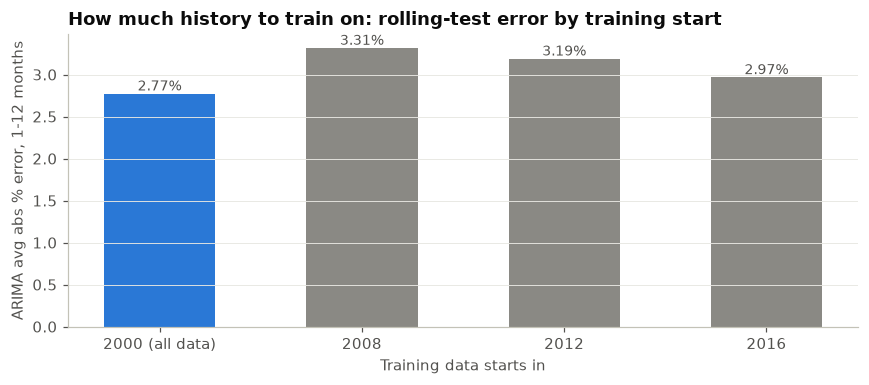

In [38]:
WINDOWS = {"2000 (all data)": "2000-01-31", "2008": "2008-01-31", "2012": "2012-01-31", "2016": "2016-01-31"}
wrows = []
for lab, start in WINDOWS.items():
    spec = pm.auto_arima(df.logp.loc[start:].iloc[:N_TRAIN - df.index.get_loc(pd.Timestamp(start))],
                         seasonal=False, suppress_warnings=True)
    for o in origins:
        d, fut = df.loc[start:].iloc[:o - df.index.get_loc(pd.Timestamp(start))], df.iloc[o:o + 12]
        fc = np.exp(pm.ARIMA(order=spec.order, with_intercept=spec.with_intercept,
                             suppress_warnings=True).fit(d.logp.values).predict(12))
        ape = 100 * np.abs(fc - fut.zhvi.values) / fut.zhvi.values
        wrows.append({"start": lab, "months": len(d), "h12": ape[-1], "avg 1-12": ape.mean()})
win = pd.DataFrame(wrows).groupby("start", sort=False)[["avg 1-12", "h12"]].mean()
print(win.round(2).to_string())

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.bar(win.index, win["avg 1-12"], color=[BLUE if v == win["avg 1-12"].min() else GRAY for v in win["avg 1-12"]], width=0.55)
for i, v in enumerate(win["avg 1-12"]):
    ax.text(i, v, f"{v:.2f}%", ha="center", va="bottom", fontsize=9, color=MUTED)
ax.set_xlabel("Training data starts in"); ax.set_ylabel("ARIMA avg abs % error, 1-12 months")
ax.set_title("How much history to train on: rolling-test error by training start")
ax.grid(axis="x", visible=False)
fig.tight_layout(); fig.savefig(FIG / "16_training_window.png"); plt.show()

## 8. Save results for the report

In [39]:
blind.round(3).to_csv(FIG / "blind_test_metrics.csv")
roll_summary.round(3).to_csv(FIG / "rolling_test_mape.csv")
out.round(0).to_csv(FIG / "outlook_12m.csv")
shock.round(2).to_csv(FIG / "nbhd_rate_shock.csv")
nb_summary.round(3).to_csv(FIG / "nbhd_forecast_accuracy.csv")
nb_out.round(2).to_csv(FIG / "nbhd_outlook_12m.csv")
trend.round(2).to_csv(FIG / "nbhd_trend_now.csv")
irf_tbl.round(3).to_csv(FIG / "irf_rate_shock.csv", index=False)
fe_tbl.round(4).to_csv(FIG / "panel_fe.csv")
cs_tbl.round(4).to_csv(FIG / "cross_section_drop.csv")
chow_tbl.round(4).to_csv(FIG / "chow_tests.csv")
win.round(3).to_csv(FIG / "training_window.csv")
llm_summary.round(3).to_csv(FIG / "llm_test.csv")
jobs_gc.round(4).to_csv(FIG / "jobs_granger.csv")
jobs_robust.round(4).to_csv(FIG / "jobs_robustness.csv")
irf_jobs.round(3).to_csv(FIG / "irf_jobs.csv", index=False)
county_jobs.round(3).to_csv(FIG / "county_jobs.csv")